# Taller 1 — Machine Learning Applied
## Parte B — Clasificación: *Thyroid Disease Data* (recurrencia de cáncer diferenciado de tiroides)

**Curso:** Machine Learning Applied
**Integrantes:** Equipo 3 — Jorge Andrés Durán y Juan Miguel Castro
**Fecha:** 2026

---

### Objetivo del notebook

Aplicar el ciclo completo de un proyecto de Machine Learning supervisado de **clasificación binaria** sobre el
dataset *Differentiated Thyroid Cancer Recurrence*: EDA y limpieza, codificación diferenciada de variables
nominales y ordinales, partición estratificada train/validation/test, `Pipeline` + `ColumnTransformer` sin fuga
de datos, entrenamiento y comparación de **KNN Classifier**, **Regresión Logística L2 (ridge)** y **Regresión
Logística L1 (lasso)**, detección de overfitting/underfitting, evaluación honesta en test, validación cruzada
estratificada con `RandomizedSearchCV` y predicción sobre un paciente inventado.

### Mapa del notebook

| Fase | Contenido | Puntos del taller |
|---|---|---|
| 1 | EDA, limpieza y preprocesamiento | 1 – 10 |
| 2 | División de datos y Pipelines | 11 – 13 |
| 4 | Modelado: KNN, Log. L2, Log. L1 | 16 – 17 |
| 5 | Métricas en train y validación (over/underfitting) | 19, 20, 21 |
| 6 | Evaluación final en Test | 22 – 23 |
| 7 | Cross Validation y optimización de hiperparámetros | 24, 26, 27 |
| 8 | Predicción sobre paciente inventado | 28 |
| 9 | Conclusiones + subplot (2,2) | 29 |

> **Nota de reproducibilidad:** todas las particiones y búsquedas usan `RANDOM_STATE = 42` y son **estratificadas**.

## 0. Configuración del entorno

Misma paleta validada para daltonismo que en el notebook de regresión, para que los dos entregables se lean
como un mismo sistema visual.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)
from sklearn.base import clone
from scipy.stats import randint, loguniform

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETA = ["#2563EB", "#D97706", "#0D9488", "#BE123C", "#7C3AED"]
TINTA, TINTA_SUAVE, REJILLA = "#1F2328", "#57606A", "#D8DEE4"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": REJILLA, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.8, "grid.alpha": 0.7,
    "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.labelsize": 10, "axes.labelcolor": TINTA_SUAVE,
    "xtick.color": TINTA_SUAVE, "ytick.color": TINTA_SUAVE,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 10,
})

print("Entorno listo · numpy", np.__version__, "· pandas", pd.__version__)

Entorno listo · numpy 2.4.4 · pandas 3.0.2


---
# FASE 1 — EDA, limpieza y preprocesamiento

## 1. Contexto clínico y variable objetivo

**El problema de salud.** El **cáncer diferenciado de tiroides** (papilar, folicular, de células de Hürthle) es
el cáncer endocrino más frecuente y tiene un pronóstico excelente: la supervivencia a 10 años supera el 90 %.
Su desafío clínico no es la mortalidad, sino la **recurrencia**: entre el 20 % y el 30 % de los pacientes
vuelven a presentar enfermedad años después del tratamiento inicial. Por eso, el seguimiento oncológico se
extiende durante **décadas**.

Ese seguimiento tiene un costo real y una decisión detrás: ¿a qué paciente se le hace vigilancia intensiva
(ecografías frecuentes, tiroglobulina seriada, rastreos con yodo radiactivo) y a quién se le puede espaciar el
control sin ponerlo en riesgo? Un modelo que estime el **riesgo de recurrencia** a partir de los datos
clínico-patológicos disponibles al momento del diagnóstico permite **estratificar el seguimiento**: intensivo
para los de alto riesgo, aliviado para los de bajo riesgo.

**Variable objetivo (target).** `Recurred`: **Yes** / **No** — si el paciente presentó recurrencia durante el
seguimiento. Es una variable **categórica binaria** ⇒ **clasificación binaria supervisada**.

Se codifica **`Yes` = 1 (clase positiva)** porque la clase de interés clínico —y la que queremos detectar— es
la recurrencia.

**Población del estudio.** 383 pacientes con cáncer diferenciado de tiroides seguidos durante al menos 10 años,
con 16 variables clínico-patológicas: demográficas (edad, sexo), factores de riesgo (tabaquismo, radioterapia
previa), función tiroidea, hallazgos del examen físico, adenopatías, tipo histológico, focalidad, clasificación
de riesgo ATA y **estadificación TNM**.

> ⚠️ **Decisión metodológica crítica — la columna `Response` se excluye como predictor.**
> `Response` registra la **respuesta al tratamiento** (Excellent / Indeterminate / Biochemical Incomplete /
> Structural Incomplete). Es una variable medida **después** del tratamiento y, en la práctica clínica, una
> "respuesta estructural incompleta" es prácticamente la definición operativa de enfermedad persistente. Usarla
> para predecir `Recurred` sería **fuga de información (*target leakage*)**: se obtendrían métricas artificialmente altas —un espejismo—, porque en el momento en que queremos hacer la predicción —al diagnóstico, para
> planear el seguimiento— esa variable **todavía no existe**. La cuantificación de esta fuga se muestra en el
> punto 6; el modelo se construye **sin** `Response`.

## 2. Carga del dataset, primeras filas y estructura

In [2]:
RUTAS_CANDIDATAS = [
    "Thyroid_Diff.csv", "data/Thyroid_Diff.csv", "../data/Thyroid_Diff.csv",
    "/content/Thyroid_Diff.csv", "/content/drive/MyDrive/Thyroid_Diff.csv",
]
ruta = next((p for p in RUTAS_CANDIDATAS if os.path.exists(p)), None)
if ruta is None:
    raise FileNotFoundError(
        "No se encontró 'Thyroid_Diff.csv'. Súbelo a la misma carpeta del notebook "
        "(en Colab: panel izquierdo > Archivos > Subir) o agrega su ruta a RUTAS_CANDIDATAS."
    )

df_raw = pd.read_csv(ruta)
print("Archivo cargado desde:", ruta)
print("Dimensiones (filas, columnas):", df_raw.shape)
df_raw.head()

Archivo cargado desde: Thyroid_Diff.csv
Dimensiones (filas, columnas): (383, 17)


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [3]:
df_raw.tail()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Recurred           

### Diccionario de datos

| Columna | Tipo esperado | Significado clínico | Rol |
|---|---|---|---|
| `Age` | entero | Edad del paciente al diagnóstico (años). Es un factor pronóstico reconocido: la edad entra explícitamente en la estadificación AJCC/TNM del cáncer de tiroides. | Predictor **numérico** |
| `Gender` | categórica (F/M) | Sexo. El cáncer de tiroides es ~3× más frecuente en mujeres, pero los hombres tienden a peor pronóstico. | Predictor **nominal** |
| `Smoking` | categórica (Yes/No) | Tabaquismo actual. | Predictor **nominal** |
| `Hx Smoking` | categórica (Yes/No) | Antecedente (*history of*) de tabaquismo. | Predictor **nominal** |
| `Hx Radiothreapy` | categórica (Yes/No) | Antecedente de radioterapia (nótese el **error tipográfico** en el nombre original: *Radiothreapy*). La irradiación cervical previa es factor de riesgo clásico. | Predictor **nominal** |
| `Thyroid Function` | categórica (5 niveles) | Estado funcional: Euthyroid, Hipo/Hipertiroidismo clínico o subclínico. | Predictor **nominal** |
| `Physical Examination` | categórica (5 niveles) | Hallazgo palpatorio: bocio único (izq./der.), multinodular, difuso o normal. | Predictor **nominal** |
| `Adenopathy` | categórica (6 niveles) | Presencia y localización de ganglios linfáticos afectados (No, Right, Left, Bilateral, Posterior, Extensive). | Predictor **nominal** |
| `Pathology` | categórica (4 niveles) | Tipo histológico: Papillary, Micropapillary, Follicular, Hürthle cell. | Predictor **nominal** |
| `Focality` | categórica (2 niveles) | Uni-Focal / Multi-Focal: si el tumor aparece en uno o varios focos. | Predictor **nominal** |
| `Risk` | categórica **ordinal** (3) | Estratificación de riesgo ATA: **Low < Intermediate < High**. | Predictor **ordinal** |
| `T` | categórica **ordinal** (7) | Tamaño/extensión del tumor primario: **T1a < T1b < T2 < T3a < T3b < T4a < T4b**. | Predictor **ordinal** |
| `N` | categórica **ordinal** (3) | Compromiso ganglionar: **N0 < N1a < N1b**. | Predictor **ordinal** |
| `M` | categórica **ordinal** (2) | Metástasis a distancia: **M0 < M1**. | Predictor **ordinal** |
| `Stage` | categórica **ordinal** (5) | Estadio global AJCC: **I < II < III < IVA < IVB**. | Predictor **ordinal** |
| `Response` | categórica (4 niveles) | Respuesta al tratamiento — **variable post-tratamiento**. | ❌ **Excluida (leakage)** |
| `Recurred` | categórica binaria | **TARGET.** Recurrencia durante el seguimiento (Yes/No). | Variable a predecir |

**Observación sobre los tipos:** salvo `Age`, **todas** las variables son categóricas (`object`). Esto marca
la diferencia fundamental con el notebook de regresión y hace que la decisión del punto 9 —qué codificar como
nominal y qué como ordinal— sea **la decisión de preprocesamiento más importante de este dataset**.

## 3. Estadísticos descriptivos e interpretación

In [5]:
print("=== Variables NUMÉRICAS ===")
display(df_raw.describe().T)
print("\n=== Variables CATEGÓRICAS ===")
display(df_raw.describe(include="object").T)

=== Variables NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
Age,383.0,40.866841,15.134494,15.0,29.0,37.0,51.0,82.0



=== Variables CATEGÓRICAS ===


/tmp/ipykernel_1124/2883225108.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_raw.describe(include="object").T)


,count,unique,top,freq
Gender,383,2,F,312
Smoking,383,2,No,334
Hx Smoking,383,2,No,355
Hx Radiothreapy,383,2,No,376
Thyroid Function,383,5,Euthyroid,332
Physical Examination,383,5,Multinodular goiter,140
Adenopathy,383,6,No,277
Pathology,383,4,Papillary,287
Focality,383,2,Uni-Focal,247
Risk,383,3,Low,249


### Interpretación de los estadísticos (3+ lecturas en términos clínicos)

1. **`Age` — media 40.9 años, mediana 37, rango 15–82, desviación 15.1.**
   La media supera a la mediana en ~4 años: la distribución de edad está **sesgada a la derecha**, con una
   cola de pacientes mayores. Clínicamente es coherente y **relevante para el pronóstico**: las guías AJCC usan
   un punto de corte de edad (55 años) porque el riesgo de recurrencia y mortalidad aumenta con ella. El
   cuartil 75 en 51 años indica que **tres de cada cuatro pacientes son menores de 55**, es decir, la cohorte
   es mayoritariamente de bajo riesgo por edad. El rango mínimo de 15 años confirma que es una enfermedad que
   afecta también a adultos jóvenes — a diferencia de la mayoría de cánceres sólidos.

2. **`Recurred` — 275 "No" frente a 108 "Yes" (≈ 71.8 % / 28.2 %).**
   Es un **desbalance moderado**, perfectamente alineado con la literatura (20–30 % de recurrencia). Tiene dos
   consecuencias metodológicas inmediatas: (i) la **partición debe ser estratificada**, o un split aleatorio
   podría dejar muy pocos casos positivos en validación/test; (ii) la ***accuracy* deja de ser una métrica
   informativa**: un clasificador trivial que prediga siempre "No recurre" alcanza ~72 % de exactitud sin haber
   aprendido nada. Habrá que mirar recall y F1.

3. **`Risk` — el valor más frecuente es "Low" con 249 de 383 casos (65 %); `N` — "N0" en 268 casos; `M` — "M0"
   en 365 de 383.**
   La cohorte está dominada por **enfermedad localizada y de bajo riesgo**. Sólo 18 pacientes (4.7 %) presentan
   metástasis a distancia. Esto implica que las categorías más graves (M1, T4b, Stage IVB) serán **muy poco
   frecuentes**: el modelo tendrá pocos ejemplos para aprenderlas y el One-Hot generará columnas casi
   constantes. Es un argumento directo a favor de codificar TNM y Risk como **ordinales** (ver punto 9): así
   la información de gravedad se concentra en una sola dimensión continua en lugar de dispersarse en muchas
   columnas binarias casi vacías.

4. *(Bonus)* **`Response` — "Excellent" en 208 de 383 casos (54 %).** Cruzando esta variable con el target (punto 6, ya sin duplicados) se ve que de los 189 pacientes con respuesta excelente **sólo 1 recurrió**: una asociación casi
   perfecta que confirma el diagnóstico de *leakage* anunciado en el punto 1.

## 4. Valores nulos: conteo, porcentaje y estrategia

In [6]:
nulos = pd.DataFrame({
    "nulos": df_raw.isna().sum(),
    "% nulos": (df_raw.isna().mean() * 100).round(3),
    "dtype": df_raw.dtypes.astype(str),
    "valores únicos": df_raw.nunique(),
})
display(nulos)
print("Total de valores nulos en el dataset:", int(df_raw.isna().sum().sum()))

,nulos,% nulos,dtype,valores únicos
Age,0,0.0,int64,65
Gender,0,0.0,str,2
Smoking,0,0.0,str,2
Hx Smoking,0,0.0,str,2
Hx Radiothreapy,0,0.0,str,2
Thyroid Function,0,0.0,str,5
Physical Examination,0,0.0,str,5
Adenopathy,0,0.0,str,6
Pathology,0,0.0,str,4
Focality,0,0.0,str,2


Total de valores nulos en el dataset: 0


In [7]:
# Búsqueda de nulos "disfrazados": cadenas vacías, espacios o centinelas textuales
centinelas = ["", " ", "?", "NA", "N/A", "na", "null", "None", "-", "Unknown", "unknown"]
ocultos = {}
for c in df_raw.select_dtypes(include="object").columns:
    n = df_raw[c].astype(str).str.strip().isin(centinelas).sum()
    if n > 0:
        ocultos[c] = int(n)
print("Nulos disfrazados encontrados:", ocultos if ocultos else "ninguno")

Nulos disfrazados encontrados: ninguno


/tmp/ipykernel_1124/1352643955.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_raw.select_dtypes(include="object").columns:


### Justificación de la estrategia frente a los nulos

El dataset está **completo**: 0 valores faltantes en las 17 columnas, y tampoco hay nulos "disfrazados" de
cadena vacía, `?`, `Unknown` u otros centinelas. Es coherente con su origen — es un registro clínico curado
de un único centro, no un volcado transaccional.

**Decisión: no se elimina ni se imputa ningún registro por nulos.** No hay nada que imputar.

**Aun así, el `ColumnTransformer` de la Fase 2 incluirá `SimpleImputer`.** No es redundante, y en un contexto
clínico es especialmente importante: el modelo se desplegaría sobre **historias clínicas reales**, donde los
campos faltantes son la norma (un paciente derivado sin estadificación completa, un examen físico no
registrado). El pipeline debe tener una política definida para ese caso en lugar de fallar. La política sería:

- **Variables numéricas (`Age`)** → **mediana**. Preferible a la media porque, como vimos en el punto 3, la
  distribución de edad está sesgada a la derecha y la media se desplaza hacia los pacientes mayores.
- **Variables categóricas (nominales y ordinales)** → **moda**. Es la única imputación con significado para
  una categoría: no existe una "categoría promedio" entre *Papillary* y *Follicular*. En variables como `M`,
  donde la moda es `M0` con 95 % de frecuencia, imputar la moda equivale a asumir "ausencia de metástasis
  mientras no se documente lo contrario", que es además la convención clínica por defecto.

**Nota de cautela clínica:** en un despliegue real, imputar la estadificación TNM de un paciente sería
discutible —esa información es demasiado determinante como para inventarla— y probablemente lo correcto sería
**rechazar la predicción** y solicitar el dato. Lo dejamos documentado como limitación.

## 5. Duplicados

In [8]:
dups = df_raw.duplicated()
print(f"Filas duplicadas exactas: {int(dups.sum())}  ({100*dups.mean():.2f} % del dataset)")
print("\nEjemplos de filas duplicadas:")
display(df_raw[df_raw.duplicated(keep=False)].sort_values(list(df_raw.columns)).head(8))

n_antes = len(df_raw)
df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"\nFilas antes: {n_antes}  |  después: {len(df)}  |  eliminadas: {n_antes - len(df)}")
print("\nDistribución del target tras eliminar duplicados:")
print(df["Recurred"].value_counts(), "\n")
print((df["Recurred"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

Filas duplicadas exactas: 19  (4.96 % del dataset)

Ejemplos de filas duplicadas:


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
136,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
168,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
161,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
196,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
106,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
121,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
138,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
183,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No



Filas antes: 383  |  después: 364  |  eliminadas: 19

Distribución del target tras eliminar duplicados:
Recurred
No     256
Yes    108
Name: count, dtype: int64 

Recurred
No     70.33 %
Yes    29.67 %
Name: proportion, dtype: str


### Justificación

Se detectan **19 filas exactamente duplicadas** (5 % del dataset) y se eliminan, quedando **364 pacientes**.

**El argumento honesto primero:** el dataset **no tiene identificador de paciente**, y todas sus variables son
categóricas de baja cardinalidad. Es perfectamente posible que dos pacientes distintos —por ejemplo, dos
mujeres de 31 años, no fumadoras, eutiroideas, con micropapilar unifocal T1a N0 M0 estadio I y sin
recurrencia— compartan exactamente el mismo vector de características. Es decir, **no podemos afirmar con
certeza que sean registros repetidos**.

**Por qué aun así se eliminan:** la razón es metodológica, no de calidad del dato. Si dos filas idénticas
quedan repartidas entre train y test, el modelo —y KNN de manera literal, porque encontraría un vecino a
distancia 0— acertaría ese caso de forma trivial, **inflando artificialmente la métrica de test**. Con sólo
364 observaciones, 19 registros representan el 5 % de la muestra: el sesgo que introducirían en la estimación
del desempeño no es despreciable. Entre el riesgo de **perder 19 observaciones** y el de **reportar un
desempeño falsamente optimista en un modelo clínico**, el segundo es claramente más grave.

**Efecto sobre el balance de clases:** todas las filas eliminadas pertenecían a la clase mayoritaria
("No recurre"), así que el desbalance se **reduce** ligeramente (de 71.8 %/28.2 % a ~70.3 %/29.7 %), lo cual es
favorable.

## 6. Inconsistencias de formato en columnas categóricas

Se revisan tres aspectos: (a) espacios en blanco y diferencias de mayúsculas/minúsculas en los valores,
(b) etiquetas equivalentes escritas de forma distinta, (c) nombres de columna problemáticos.

In [9]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("=== (a) Espacios sobrantes y variantes de capitalización ===")
problemas = []
for c in cat_cols:
    s = df[c].astype(str)
    n_espacios = int((s != s.str.strip()).sum())
    n_variantes = int(s.str.strip().nunique() - s.str.strip().str.lower().nunique())
    if n_espacios or n_variantes:
        problemas.append({"columna": c, "valores con espacios": n_espacios,
                          "etiquetas que sólo difieren en mayúsculas": n_variantes})
display(pd.DataFrame(problemas) if problemas else "Sin problemas de espacios ni de capitalización.")

print("\n=== (b) Inventario completo de etiquetas por variable ===")
for c in cat_cols:
    print(f"  {c:<22} ({df[c].nunique()}): {sorted(df[c].unique().tolist())}")

=== (a) Espacios sobrantes y variantes de capitalización ===


/tmp/ipykernel_1124/1930565037.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


'Sin problemas de espacios ni de capitalización.'


=== (b) Inventario completo de etiquetas por variable ===
  Gender                 (2): ['F', 'M']
  Smoking                (2): ['No', 'Yes']
  Hx Smoking             (2): ['No', 'Yes']
  Hx Radiothreapy        (2): ['No', 'Yes']
  Thyroid Function       (5): ['Clinical Hyperthyroidism', 'Clinical Hypothyroidism', 'Euthyroid', 'Subclinical Hyperthyroidism', 'Subclinical Hypothyroidism']
  Physical Examination   (5): ['Diffuse goiter', 'Multinodular goiter', 'Normal', 'Single nodular goiter-left', 'Single nodular goiter-right']
  Adenopathy             (6): ['Bilateral', 'Extensive', 'Left', 'No', 'Posterior', 'Right']
  Pathology              (4): ['Follicular', 'Hurthel cell', 'Micropapillary', 'Papillary']
  Focality               (2): ['Multi-Focal', 'Uni-Focal']
  Risk                   (3): ['High', 'Intermediate', 'Low']
  T                      (7): ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
  N                      (3): ['N0', 'N1a', 'N1b']
  M                      (2):

In [10]:
# --- Correcciones aplicadas ---
# (a) Normalización defensiva de espacios (no altera nada si ya están limpios,
#     pero deja el pipeline preparado para datos nuevos menos cuidados)
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()

# (b) Corrección de un error ortográfico en una ETIQUETA: 'Hurthel cell' -> 'Hurthle cell'
df["Pathology"] = df["Pathology"].replace({"Hurthel cell": "Hurthle cell"})

# (c) Corrección de nombres de columna: el original trae 'Hx Radiothreapy' (typo de 'Radiotherapy')
#     y espacios que complican el acceso por atributo.
renombres = {
    "Hx Smoking": "Hx_Smoking",
    "Hx Radiothreapy": "Hx_Radiotherapy",      # <- typo corregido
    "Thyroid Function": "Thyroid_Function",
    "Physical Examination": "Physical_Examination",
}
df = df.rename(columns=renombres)
print("Columnas tras la normalización:")
print(list(df.columns))

Columnas tras la normalización:
['Age', 'Gender', 'Smoking', 'Hx_Smoking', 'Hx_Radiotherapy', 'Thyroid_Function', 'Physical_Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']


In [11]:
# --- Cuantificación del leakage de 'Response' (justifica su exclusión) ---
tabla_leak = pd.crosstab(df["Response"], df["Recurred"], margins=True, margins_name="Total")
tabla_leak["% recurrencia"] = (100 * tabla_leak["Yes"] / tabla_leak["Total"]).round(1)
print("Respuesta al tratamiento vs. recurrencia:")
display(tabla_leak)

coincidencia = ((df["Response"] == "Structural Incomplete") == (df["Recurred"] == "Yes")).mean()
print(f"\nUna regla trivial ('Structural Incomplete' <=> recurrencia) acierta el {100*coincidencia:.1f} % de los casos.")
print("-> 'Response' no es un predictor, es prácticamente una reformulación del target medida a posteriori.")

Respuesta al tratamiento vs. recurrencia:


Recurred,No,Yes,Total,% recurrencia
Response,,,,
Biochemical Incomplete,12,11,23,47.8
Excellent,188,1,189,0.5
Indeterminate,54,7,61,11.5
Structural Incomplete,2,89,91,97.8
Total,256,108,364,29.7



Una regla trivial ('Structural Incomplete' <=> recurrencia) acierta el 94.2 % de los casos.
-> 'Response' no es un predictor, es prácticamente una reformulación del target medida a posteriori.


### Justificación de las correcciones

- **(a) Normalización de espacios.** El archivo viene limpio (0 valores con espacios sobrantes, 0 etiquetas que
  difieran sólo en mayúsculas). Aun así se aplica `.str.strip()` de forma **defensiva**: no cambia nada hoy,
  pero si el dataset se actualiza o se integra con otra fuente, evita que `"Papillary"` y `"Papillary "` se
  traten como dos categorías distintas —lo que crearía una columna One-Hot espuria y dejaría al modelo sin
  saber qué hacer con ella.
- **(b) `Hurthel cell` → `Hurthle cell`.** Es un error ortográfico del término médico (*células de Hürthle*).
  No afecta al modelo —es una única etiqueta consistente— pero sí a la legibilidad de las gráficas y tablas
  que verá un lector clínico. Corregirlo es parte de entregar un análisis profesional.
- **(c) Nombres de columna.** `Hx Radiothreapy` tiene un error tipográfico y varias columnas tienen espacios.
  Se renombran a `snake_case` corrigiendo el typo. Esto no altera el contenido, sólo facilita el código y
  evita errores de tipeo al referenciar columnas.
- **(d) Exclusión de `Response`.** La tabla anterior cuantifica lo anunciado: **de 189 pacientes con respuesta
  "Excellent", sólo 1 recurrió; de 91 con respuesta "Structural Incomplete", 89 recurrieron.** Una regla de una
  sola línea alcanza 94.2 % de acierto. Incluir esta variable produciría un modelo espectacular e **inútil**:
  en el momento clínico en que se quiere predecir (al diagnóstico, para planear el seguimiento) la respuesta al
  tratamiento aún no se ha observado. Se excluye del conjunto de predictores.

## 6b. Construcción de variables numéricas auxiliares para el EDA

El dataset tiene **una sola** variable numérica (`Age`), lo que impide aplicar el análisis de outliers del
punto 7 a "al menos dos columnas numéricas". La solución no es inventar datos, sino **hacer explícito el orden
que ya existe** en las variables ordinales: `Risk`, `T`, `N`, `M` y `Stage` no son etiquetas intercambiables,
son escalas de gravedad. Al mapearlas a enteros obtenemos variables numéricas legítimas sobre las que el
criterio IQR sí tiene sentido.

Se construye además un **índice de agresividad tumoral** = `T_ord + N_ord + M_ord`, resumen del estadiaje TNM
en una única escala continua. Se usa **sólo para el EDA** (gráficas y análisis de outliers): **no entra al
modelo**, porque sería una combinación lineal redundante de variables que ya están incluidas por separado, y
duplicarla distorsionaría tanto las distancias de KNN como la regularización de la regresión logística.

In [12]:
ORDENES = {
    "Risk":  ["Low", "Intermediate", "High"],
    "T":     ["T1a", "T1b", "T2", "T3a", "T3b", "T4a", "T4b"],
    "N":     ["N0", "N1a", "N1b"],
    "M":     ["M0", "M1"],
    "Stage": ["I", "II", "III", "IVA", "IVB"],
}

for col, orden in ORDENES.items():
    faltantes = set(df[col].unique()) - set(orden)
    assert not faltantes, f"Categorías no contempladas en {col}: {faltantes}"
    df[f"{col}_ord"] = df[col].map({v: i for i, v in enumerate(orden)})

df["indice_agresividad"] = df["T_ord"] + df["N_ord"] + df["M_ord"]
df["Recurred_bin"] = (df["Recurred"] == "Yes").astype(int)

print("Mapeos ordinales aplicados:")
for col, orden in ORDENES.items():
    print(f"  {col:<6}: " + "  <  ".join(f"{v}={i}" for i, v in enumerate(orden)))
df[["Age", "Risk_ord", "T_ord", "N_ord", "M_ord", "Stage_ord",
    "indice_agresividad", "Recurred", "Recurred_bin"]].head()

Mapeos ordinales aplicados:
  Risk  : Low=0  <  Intermediate=1  <  High=2
  T     : T1a=0  <  T1b=1  <  T2=2  <  T3a=3  <  T3b=4  <  T4a=5  <  T4b=6
  N     : N0=0  <  N1a=1  <  N1b=2
  M     : M0=0  <  M1=1
  Stage : I=0  <  II=1  <  III=2  <  IVA=3  <  IVB=4


,Age,Risk_ord,T_ord,N_ord,M_ord,Stage_ord,indice_agresividad,Recurred,Recurred_bin
0,27,0,0,0,0,0,0,No,0
1,34,0,0,0,0,0,0,No,0
2,30,0,0,0,0,0,0,No,0
3,62,0,0,0,0,0,0,No,0
4,62,0,0,0,0,0,0,No,0


## 7. Detección de outliers con el criterio IQR

In [13]:
def reporte_iqr(serie, nombre):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    bajos, altos = int((serie < li).sum()), int((serie > ls).sum())
    return {"variable": nombre, "mín": serie.min(), "Q1": q1, "mediana": serie.median(), "Q3": q3,
            "máx": serie.max(), "IQR": iqr, "límite inferior": li, "límite superior": ls,
            "outliers bajos": bajos, "outliers altos": altos,
            "% outliers": round(100 * (bajos + altos) / len(serie), 2)}

pd.DataFrame([
    reporte_iqr(df["Age"], "Age (años)"),
    reporte_iqr(df["indice_agresividad"], "indice_agresividad (T+N+M)"),
    reporte_iqr(df["Stage_ord"], "Stage_ord (estadio AJCC)"),
]).set_index("variable")

,mín,Q1,mediana,Q3,máx,IQR,límite inferior,límite superior,outliers bajos,outliers altos,% outliers
variable,,,,,,,,,,,
Age (años),15,30.0,38.0,52.0,82,22.0,-3.0,85.0,0,0,0.00
indice_agresividad (T+N+M),0,2.0,2.0,4.0,9,2.0,-1.0,7.0,0,11,3.02
Stage_ord (estadio AJCC),0,0.0,0.0,0.0,4,0.0,0.0,0.0,0,50,13.74


In [14]:
# ¿Quiénes son los "outliers"? ¿Qué proporción recurre?
ls_edad = df["Age"].quantile(0.75) + 1.5 * (df["Age"].quantile(0.75) - df["Age"].quantile(0.25))
ls_agr = df["indice_agresividad"].quantile(0.75) + 1.5 * (df["indice_agresividad"].quantile(0.75) - df["indice_agresividad"].quantile(0.25))

out_edad = df[df["Age"] > ls_edad]
out_agr = df[df["indice_agresividad"] > ls_agr]

resumen_out = pd.DataFrame([
    {"grupo": f"Edad > {ls_edad:.0f} años (outliers IQR)", "n": len(out_edad),
     "% del total": round(100 * len(out_edad) / len(df), 1),
     "% que recurre": round(100 * out_edad["Recurred_bin"].mean(), 1) if len(out_edad) else np.nan},
    {"grupo": f"Índice agresividad > {ls_agr:.0f} (outliers IQR)", "n": len(out_agr),
     "% del total": round(100 * len(out_agr) / len(df), 1),
     "% que recurre": round(100 * out_agr["Recurred_bin"].mean(), 1) if len(out_agr) else np.nan},
    {"grupo": "TODA la cohorte (referencia)", "n": len(df), "% del total": 100.0,
     "% que recurre": round(100 * df["Recurred_bin"].mean(), 1)},
])
resumen_out

,grupo,n,% del total,% que recurre
0,Edad > 85 años (outliers IQR),0,0.0,NaN
1,Índice agresividad > 7 (outliers IQR),11,3.0,100.0
2,TODA la cohorte (referencia),364,100.0,29.7


### Decisión y justificación: **se documentan, NO se eliminan**

**Qué marca el criterio IQR.**

- **`Age`:** el límite superior del IQR es 85 años y el máximo observado es 82, así que el criterio **no marca ningún outlier** (0 pacientes, ver tabla). Todas las edades son biológicamente posibles.
- **`indice_agresividad` y `Stage_ord`:** aquí el criterio marca un grupo más numeroso — los pacientes con
  estadios avanzados (T4, N1b, M1, Stage IV). Y es exactamente lo que cabía esperar de una cohorte dominada
  por enfermedad de bajo riesgo: como el 65 % son "Low risk", **cualquier paciente grave queda fuera del
  rango intercuartílico**.

**Decisión: conservarlos todos.** Justificación en tres puntos:

1. **No son errores, son los pacientes que más importan.** Un paciente con M1 o Stage IVB no es un error de
   captura: es precisamente el caso que el modelo debe aprender a detectar. La tabla anterior lo muestra de
   forma contundente: **el grupo de "outliers" por agresividad tiene una tasa de recurrencia varias veces
   superior a la de la cohorte general**. Eliminarlos destruiría la señal clínica más valiosa del dataset y
   produciría un modelo que sistemáticamente **subestima el riesgo en los pacientes graves** — el fallo más
   peligroso posible en este contexto.
2. **El IQR no es el criterio adecuado para variables ordinales acotadas.** `Stage_ord` sólo puede tomar 5
   valores y `M_ord` sólo 2. Que el 95 % de los pacientes esté en `M0` no convierte a los 18 pacientes con
   `M1` en anomalías estadísticas: convierte a la variable en **desbalanceada**, que es un problema distinto
   (y se aborda con estratificación, no con eliminación).
3. **Ningún valor viola su dominio.** Todas las edades están entre 15 y 82 años; todas las categorías TNM
   pertenecen a la nomenclatura AJCC válida. No hay nada que corregir.

**Consecuencia para el punto 10.** Como `Age` **no presenta outliers reales** —su distribución, aunque
ligeramente sesgada, no tiene valores extremos que distorsionen la media— **`StandardScaler` es apropiado
aquí**, a diferencia del notebook de regresión, donde la cola de tarifas obligaba a usar `RobustScaler`.
La decisión de escalamiento no es una preferencia: se deriva de lo que muestran los datos.

## 8. Gráficas de EDA

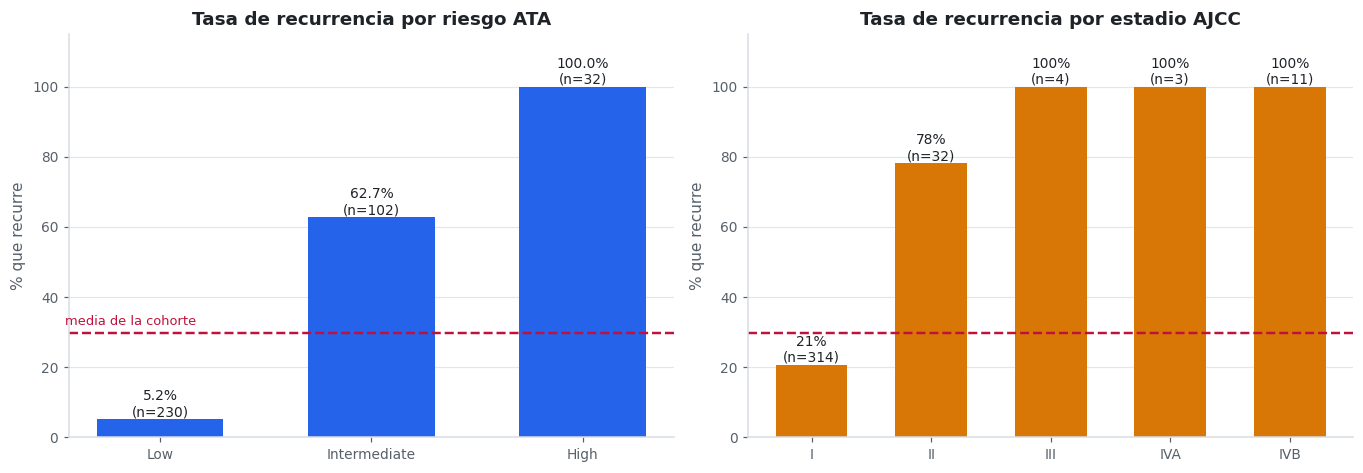

,n,tasa,variable
Low,230,0.052,Risk
Intermediate,102,0.627,Risk
High,32,1.000,Risk
I,314,0.207,Stage
II,32,0.781,Stage
III,4,1.000,Stage
IVA,3,1.000,Stage
IVB,11,1.000,Stage


In [15]:
# ---------- GRÁFICA 1: BARRAS — tasa de recurrencia por nivel de riesgo y por estadio ----------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

g1 = df.groupby("Risk", observed=True).agg(n=("Recurred_bin", "size"),
                                           tasa=("Recurred_bin", "mean")).reindex(ORDENES["Risk"])
axes[0].bar(g1.index, g1["tasa"] * 100, color=PALETA[0], width=0.6)
for x, (t, n) in zip(g1.index, zip(g1["tasa"], g1["n"])):
    axes[0].text(x, t * 100, f"{t*100:.1f}%\n(n={n})", ha="center", va="bottom", fontsize=9, color=TINTA)
axes[0].set_title("Tasa de recurrencia por riesgo ATA"); axes[0].set_ylabel("% que recurre")
axes[0].set_ylim(0, 115)

g2 = df.groupby("Stage", observed=True).agg(n=("Recurred_bin", "size"),
                                            tasa=("Recurred_bin", "mean")).reindex(ORDENES["Stage"])
axes[1].bar(g2.index, g2["tasa"] * 100, color=PALETA[1], width=0.6)
for x, (t, n) in zip(g2.index, zip(g2["tasa"], g2["n"])):
    axes[1].text(x, t * 100, f"{t*100:.0f}%\n(n={n})", ha="center", va="bottom", fontsize=9, color=TINTA)
axes[1].set_title("Tasa de recurrencia por estadio AJCC"); axes[1].set_ylabel("% que recurre")
axes[1].set_ylim(0, 115)

for ax in axes:
    ax.axhline(100 * df["Recurred_bin"].mean(), color=PALETA[3], linestyle="--", linewidth=1.6)
    ax.grid(axis="x", visible=False)
axes[0].text(-0.45, 100 * df["Recurred_bin"].mean() + 1.5, "media de la cohorte", color=PALETA[3],
             fontsize=8.5, va="bottom", ha="left")
fig.tight_layout(); plt.show()
display(pd.concat([g1.assign(variable="Risk"), g2.assign(variable="Stage")]).round(3))

**Interpretación (Gráfica 1).** La relación es **monótona y muy marcada**: la tasa de recurrencia pasa de un
valor bajo en riesgo *Low* a prácticamente la totalidad de los pacientes en riesgo *High*, y el mismo patrón
se repite por estadio AJCC. Dicho de otra forma, `Risk` y `Stage` por sí solas ya separan bastante bien las dos
clases. Nótese también el **desbalance de tamaño muestral**: los estadios avanzados tienen muy pocos pacientes
(n pequeño), de modo que sus tasas, aunque extremas, se estiman con mucha incertidumbre.

**Recomendación.** Este es el argumento empírico definitivo para codificar `Risk` y `Stage` como **ordinales**
(punto 9): la relación con el target es monótona, exactamente lo que una escala numérica ordenada puede
representar con **una sola** columna y un solo coeficiente. Desde lo clínico, la gráfica sugiere que la
estratificación ATA ya es un buen predictor por sí misma; el valor añadido del modelo estará en afinar la
decisión **dentro** del grupo de riesgo bajo/intermedio, que es donde se concentra la mayoría de pacientes y
donde la decisión de seguimiento es menos obvia.

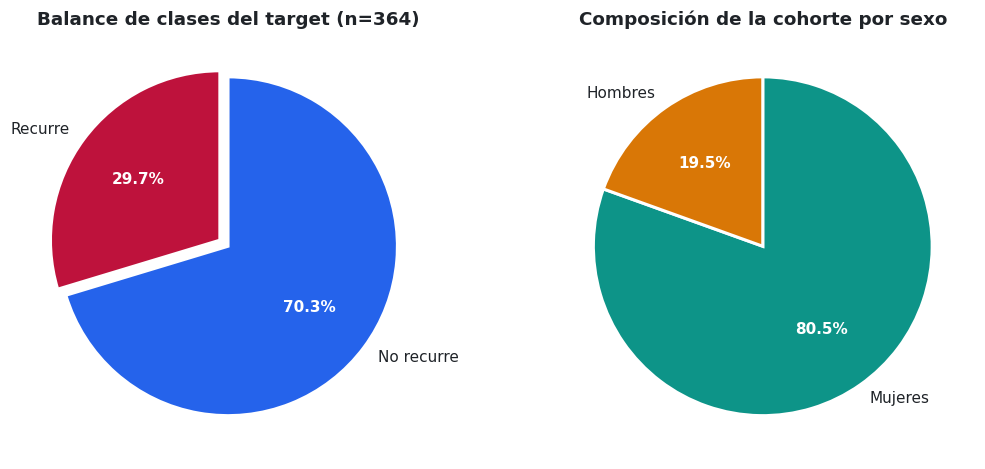

Tasa de recurrencia por sexo:


,n,tasa de recurrencia
Gender,,
F,293,0.225
M,71,0.592


In [16]:
# ---------- GRÁFICA 2: PIE — balance de clases y composición por sexo ----------
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0))

conteo = df["Recurred"].value_counts().reindex(["No", "Yes"])
w, t, at = axes[0].pie(conteo.values, labels=["No recurre", "Recurre"],
                       colors=[PALETA[0], PALETA[3]], autopct="%1.1f%%",
                       startangle=90, counterclock=False, explode=(0, 0.06),
                       wedgeprops={"linewidth": 2, "edgecolor": "white"},
                       textprops={"fontsize": 10, "color": TINTA})
for a in at: a.set_color("white"); a.set_fontweight("bold")
axes[0].set_title(f"Balance de clases del target (n={len(df)})")

sexo = df["Gender"].value_counts()
w2, t2, at2 = axes[1].pie(sexo.values, labels=["Mujeres" if k == "F" else "Hombres" for k in sexo.index],
                          colors=[PALETA[2], PALETA[1]], autopct="%1.1f%%",
                          startangle=90, counterclock=False,
                          wedgeprops={"linewidth": 2, "edgecolor": "white"},
                          textprops={"fontsize": 10, "color": TINTA})
for a in at2: a.set_color("white"); a.set_fontweight("bold")
axes[1].set_title("Composición de la cohorte por sexo")
for ax in axes: ax.grid(False)
plt.show()

print("Tasa de recurrencia por sexo:")
display((df.groupby("Gender")["Recurred_bin"].agg(["size", "mean"])
           .rename(columns={"size": "n", "mean": "tasa de recurrencia"}).round(3)))

**Interpretación (Gráfica 2).** Cerca del **30 % de los pacientes recurre**: el desbalance es moderado, no
extremo. La segunda gráfica muestra que la cohorte es **mayoritariamente femenina** (~81 %), consistente con
la epidemiología del cáncer de tiroides. Sin embargo, la tabla revela algo más relevante: **la tasa de
recurrencia en hombres es notablemente mayor que en mujeres**, lo que coincide con la literatura clínica
(el sexo masculino es un factor de peor pronóstico).

**Recomendación.** Dos decisiones se derivan de aquí: (i) **estratificar** todas las particiones por el target,
para que las tres (train/val/test) preserven la proporción ~70/30 — con 364 observaciones, un split no
estratificado podría dejar validación con muy pocos casos positivos y métricas sin sentido; (ii) **no usar
*accuracy* como criterio principal**: un modelo que prediga siempre "No recurre" tendría ~70 % de exactitud y
un recall de 0 %, es decir, sería inútil y peligroso. Se priorizarán **recall y F1**.

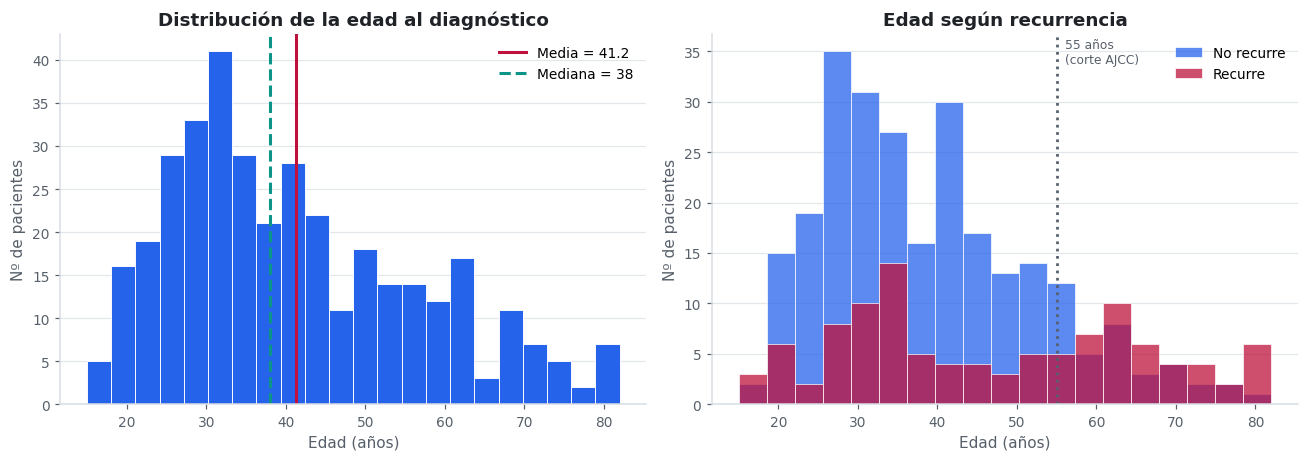

Asimetría (skewness) de Age: 0.678


,count,mean,std,min,25%,50%,75%,max
Recurred,,,,,,,,
No,256.0,38.78,13.16,17.0,28.75,36.0,46.25,81.0
Yes,108.0,47.11,18.27,15.0,31.75,44.5,62.00,82.0


In [17]:
# ---------- GRÁFICA 3: HISTOGRAMA — distribución de la edad, global y por clase ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

axes[0].hist(df["Age"], bins=22, color=PALETA[0], edgecolor="white", linewidth=0.6)
axes[0].axvline(df["Age"].mean(), color=PALETA[3], linewidth=2, label=f"Media = {df['Age'].mean():.1f}")
axes[0].axvline(df["Age"].median(), color=PALETA[2], linewidth=2, linestyle="--", label=f"Mediana = {df['Age'].median():.0f}")
axes[0].set_title("Distribución de la edad al diagnóstico"); axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Nº de pacientes"); axes[0].legend()

bins = np.linspace(df["Age"].min(), df["Age"].max(), 20)
axes[1].hist(df.loc[df["Recurred"] == "No", "Age"], bins=bins, alpha=0.75, color=PALETA[0],
             label="No recurre", edgecolor="white", linewidth=0.6)
axes[1].hist(df.loc[df["Recurred"] == "Yes", "Age"], bins=bins, alpha=0.75, color=PALETA[3],
             label="Recurre", edgecolor="white", linewidth=0.6)
axes[1].axvline(55, color=TINTA_SUAVE, linestyle=":", linewidth=1.8)
axes[1].text(56, axes[1].get_ylim()[1] * 0.92, "55 años\n(corte AJCC)", fontsize=8, color=TINTA_SUAVE)
axes[1].set_title("Edad según recurrencia"); axes[1].set_xlabel("Edad (años)")
axes[1].set_ylabel("Nº de pacientes"); axes[1].legend()
for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

print("Asimetría (skewness) de Age:", round(df["Age"].skew(), 3))
display(df.groupby("Recurred")["Age"].describe().round(2))

**Interpretación (Gráfica 3).** La edad es **unimodal con un leve sesgo a la derecha** (skewness ≈ 0.7), con el
grueso de pacientes entre los 25 y los 50 años. El histograma por clase muestra que el grupo que recurre tiene
una **media de edad mayor** y una distribución desplazada hacia la derecha, aunque con **solapamiento
considerable**: la edad *sola* no separa las clases. Es un factor de riesgo real pero **débil en comparación
con la estadificación** (Gráfica 1).

**Recomendación.** (i) Conservar `Age` como predictor, pero sin esperar que cargue el peso del modelo. (ii)
Como el sesgo es leve y **no hay valores extremos**, `StandardScaler` es apropiado — no hace falta el
`RobustScaler` que sí requería el dataset de Uber. (iii) La línea de los 55 años sugiere que una versión
futura del modelo podría beneficiarse de una variable binaria "edad ≥ 55", que es como la propia
estadificación AJCC usa la edad; lo dejamos como posible mejora.

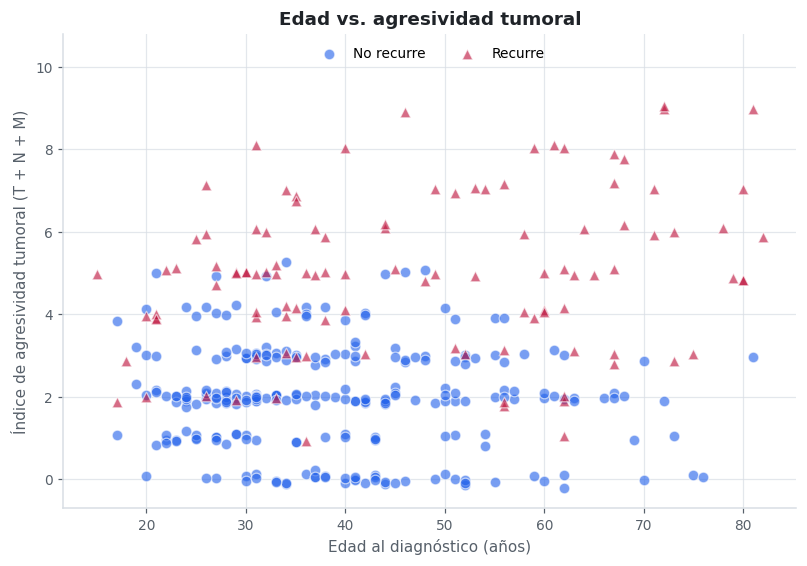

Correlación de Spearman con la recurrencia:


,ρ de Spearman
Recurred_bin,1.000
Risk_ord,0.729
indice_agresividad,0.649
N_ord,0.622
T_ord,0.536
Stage_ord,0.497
M_ord,0.351
Age,0.206


In [18]:
# ---------- GRÁFICA 4: SCATTER — edad vs. agresividad tumoral, coloreado por recurrencia ----------
rng = np.random.default_rng(RANDOM_STATE)
jitter = rng.normal(0, 0.11, len(df))

fig, ax = plt.subplots(figsize=(8.6, 5.6))
for etiqueta, color, marcador in [("No", PALETA[0], "o"), ("Yes", PALETA[3], "^")]:
    m = df["Recurred"] == etiqueta
    ax.scatter(df.loc[m, "Age"], df.loc[m, "indice_agresividad"] + jitter[m.values],
               s=48, alpha=0.62, color=color, marker=marcador, linewidths=0.8, edgecolors="white",
               label="Recurre" if etiqueta == "Yes" else "No recurre")
ax.set_xlabel("Edad al diagnóstico (años)")
ax.set_ylabel("Índice de agresividad tumoral (T + N + M)")
ax.set_title("Edad vs. agresividad tumoral")
ax.set_ylim(-0.7, 10.8)
ax.legend(loc="upper center", ncol=2)
plt.show()

print("Correlación de Spearman con la recurrencia:")
display(df[["Age", "Risk_ord", "T_ord", "N_ord", "M_ord", "Stage_ord",
            "indice_agresividad", "Recurred_bin"]].corr(method="spearman")["Recurred_bin"]
          .sort_values(ascending=False).round(3).to_frame("ρ de Spearman"))

**Interpretación (Gráfica 4).** La nube muestra con claridad **dónde está la señal**: los casos que recurren
(triángulos) se acumulan en la **parte alta del eje vertical** —índice de agresividad elevado— y se distribuyen
a lo largo de todo el eje horizontal. Es decir, **la estadificación tumoral separa las clases mucho mejor que
la edad**. En la banda inferior (índice 0–1, tumores T1–T2 sin ganglios) domina claramente la clase "No
recurre", aunque hay casos positivos dispersos: son los pacientes que un modelo debe aprender a rescatar y los
que más cuesta detectar.

La tabla de correlaciones de Spearman lo confirma numéricamente: `N_ord`, `Risk_ord` y el índice de agresividad
tienen las asociaciones más fuertes con el target, mientras que `Age` queda muy por detrás.

**Recomendación.** Como responsable de la decisión clínica, priorizaría un modelo que explote la
estadificación TNM y la clasificación ATA, y usaría la edad como modulador secundario. Para el modelado, esto
anticipa que **la regresión logística debería comportarse bien**: la relación entre las variables ordinales de
gravedad y el log-odds de recurrencia parece monótona, que es justo la forma funcional que la logística asume.

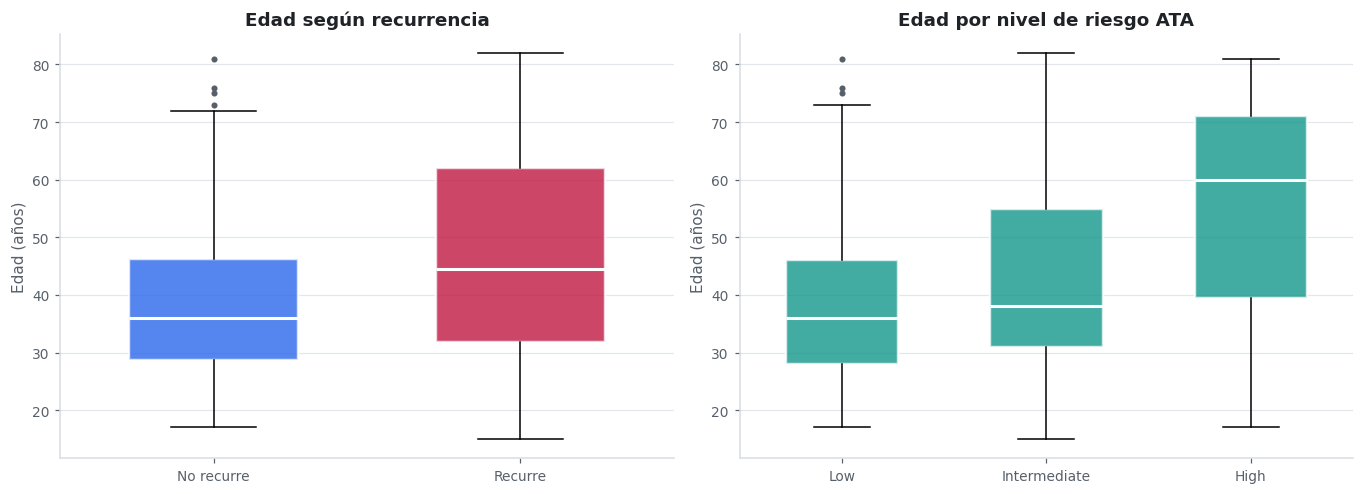

In [19]:
# ---------- GRÁFICA 5: BOXPLOT — edad por clase y por nivel de riesgo ----------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

datos = [df.loc[df["Recurred"] == v, "Age"].values for v in ["No", "Yes"]]
bp1 = axes[0].boxplot(datos, patch_artist=True, widths=0.55)
for caja, color in zip(bp1["boxes"], [PALETA[0], PALETA[3]]):
    caja.set(facecolor=color, alpha=0.78, edgecolor="white", linewidth=1.6)
for m in bp1["medians"]: m.set(color="white", linewidth=2)
for f in bp1["fliers"]: f.set(marker="o", markersize=4, markerfacecolor=TINTA_SUAVE, markeredgecolor="none")
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(["No recurre", "Recurre"])
axes[0].set_ylabel("Edad (años)"); axes[0].set_title("Edad según recurrencia")

datos2 = [df.loc[df["Risk"] == r, "Age"].values for r in ORDENES["Risk"]]
bp2 = axes[1].boxplot(datos2, patch_artist=True, widths=0.55)
for caja in bp2["boxes"]:
    caja.set(facecolor=PALETA[2], alpha=0.78, edgecolor="white", linewidth=1.6)
for m in bp2["medians"]: m.set(color="white", linewidth=2)
for f in bp2["fliers"]: f.set(marker="o", markersize=4, markerfacecolor=TINTA_SUAVE, markeredgecolor="none")
axes[1].set_xticks([1, 2, 3]); axes[1].set_xticklabels(ORDENES["Risk"])
axes[1].set_ylabel("Edad (años)"); axes[1].set_title("Edad por nivel de riesgo ATA")

for ax in axes: ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

**Interpretación (Gráfica 5).** El primer boxplot confirma lo del histograma: la mediana de edad del grupo que
recurre es mayor, **pero los rangos intercuartílicos se solapan ampliamente**. La edad desplaza la
probabilidad, no la determina. El segundo boxplot muestra que la edad también aumenta con el nivel de riesgo
ATA, lo que indica **colinealidad parcial** entre `Age` y `Risk`: parte de la información de la edad ya está
contenida en la clasificación de riesgo.

**Recomendación.** Esta colinealidad es relevante para elegir el tipo de regularización. Con predictores
correlacionados, **L2 (ridge) tiende a repartir el peso entre ellos**, mientras que **L1 (lasso) elige uno y
anula el otro**. Como aquí las variables correlacionadas son todas clínicamente informativas, **esperamos que
L2 se comporte mejor o igual que L1**, y que L1 produzca un modelo más escueto pero potencialmente algo menos
preciso. Lo verificaremos en la Fase 5.

## 9. Codificación de variables categóricas — decisión y justificación

**Ésta es la decisión de preprocesamiento central de este dataset**, porque salvo `Age` todas las variables son
categóricas. La regla que aplicamos es simple y se sustenta en el EDA:

> **¿El orden de las categorías tiene significado clínico?** Si sí → **Ordinal**. Si no → **One-Hot**.

In [20]:
NOMINALES = ["Gender", "Smoking", "Hx_Smoking", "Hx_Radiotherapy", "Thyroid_Function",
             "Physical_Examination", "Adenopathy", "Pathology", "Focality"]
ORDINALES = ["Risk", "T", "N", "M", "Stage"]
NUMERICAS = ["Age"]

resumen_cod = pd.DataFrame({
    "variable": NOMINALES + ORDINALES,
    "tipo": ["Nominal"] * len(NOMINALES) + ["Ordinal"] * len(ORDINALES),
    "cardinalidad": [df[c].nunique() for c in NOMINALES + ORDINALES],
    "codificación": ["One-Hot"] * len(NOMINALES) + ["Ordinal (orden clínico)"] * len(ORDINALES),
    "columnas generadas": [df[c].nunique() if df[c].nunique() > 2 else 1 for c in NOMINALES] + [1] * len(ORDINALES),
})
display(resumen_cod)
print(f"Dimensionalidad final estimada: {resumen_cod['columnas generadas'].sum() + len(NUMERICAS)} "
      f"features a partir de {len(NOMINALES + ORDINALES + NUMERICAS)} variables originales")

,variable,tipo,cardinalidad,codificación,columnas generadas
0,Gender,Nominal,2,One-Hot,1
1,Smoking,Nominal,2,One-Hot,1
2,Hx_Smoking,Nominal,2,One-Hot,1
3,Hx_Radiotherapy,Nominal,2,One-Hot,1
4,Thyroid_Function,Nominal,5,One-Hot,5
5,Physical_Examination,Nominal,5,One-Hot,5
6,Adenopathy,Nominal,6,One-Hot,6
7,Pathology,Nominal,4,One-Hot,4
8,Focality,Nominal,2,One-Hot,1
9,Risk,Ordinal,3,Ordinal (orden clínico),1


Dimensionalidad final estimada: 31 features a partir de 15 variables originales


### Justificación por grupo

#### A) Variables ORDINALES → `OrdinalEncoder` con orden explícito

| Variable | Orden impuesto | Por qué el orden es real |
|---|---|---|
| `Risk` | Low < Intermediate < High | Es una **escala de riesgo** definida por la American Thyroid Association; su propósito *es* ordenar. |
| `T` | T1a < T1b < T2 < T3a < T3b < T4a < T4b | Mide tamaño y extensión del tumor primario; cada nivel es estrictamente más avanzado que el anterior. |
| `N` | N0 < N1a < N1b | Ausencia de ganglios < ganglios centrales < ganglios laterales/mediastínicos. |
| `M` | M0 < M1 | Ausencia < presencia de metástasis a distancia. |
| `Stage` | I < II < III < IVA < IVB | Estadio global AJCC, construido precisamente como una escala pronóstica ordenada. |

**Por qué Ordinal y no One-Hot en estas cinco:**

1. **El orden es la información.** La Gráfica 1 mostró que la tasa de recurrencia crece **monótonamente** con
   `Risk` y con `Stage`. Un `OrdinalEncoder` captura esa monotonía con **una sola columna y un solo
   coeficiente**; el One-Hot la descartaría y obligaría al modelo a reaprenderla desde cero, estimando un
   coeficiente independiente por nivel.
2. **Economía de parámetros — decisiva con n = 364.** One-Hot sobre estas cinco variables generaría 20 columnas
   en lugar de 5. Con sólo ~254 observaciones de entrenamiento, cada parámetro adicional aumenta el riesgo de
   sobreajuste y degrada a KNN por la **maldición de la dimensionalidad**.
3. **Los niveles graves son raros.** Como vimos en el punto 3, hay 18 pacientes con M1 y muy pocos en Stage
   IVB. Un One-Hot crearía columnas con 2–5 unos entre 364 filas: casi constantes, con coeficientes
   inestimables de forma estable. La escala ordinal, en cambio, **suma la gravedad** en lugar de fragmentarla.
4. **El riesgo típico del Ordinal Encoding no aplica aquí.** La advertencia clásica —"introduce un orden falso
   en modelos lineales o de distancia"— es correcta cuando el orden **no existe** (codificar Papillary=0,
   Follicular=1, Hürthle=2 sería un disparate). Aquí el orden existe, está definido por una guía clínica
   internacional y es el mismo que usa el oncólogo. Lo que sí asumimos, y conviene declarar, es que los pasos
   son **aproximadamente equiespaciados** (que la distancia T1a→T1b "vale" lo mismo que T3b→T4a). Es una
   aproximación; a cambio, ganamos parsimonia y monotonía. Para KNN esto además tiene una ventaja concreta:
   tras el escalado, dos pacientes con estadios contiguos quedan **cerca**, que es exactamente el
   comportamiento deseado.

#### B) Variables NOMINALES → `OneHotEncoder`

`Gender`, `Smoking`, `Hx_Smoking`, `Hx_Radiotherapy`, `Thyroid_Function`, `Physical_Examination`,
`Adenopathy`, `Pathology`, `Focality`.

- **No tienen orden natural.** No hay forma de sostener que *Papillary* < *Follicular* < *Hürthle cell*, ni que
  un bocio "Single nodular-left" sea menor que uno "Multinodular". Aplicar Ordinal aquí **sí** introduciría un
  orden falso: KNN mediría distancias inventadas entre tipos histológicos y la logística estimaría una única
  pendiente asumiendo un efecto incremental inexistente.
- **Cardinalidad baja** (máximo 6 en `Adenopathy`), así que el costo en columnas es asumible.
- Se usa **`drop="if_binary"`** en las variables Yes/No y F/M: deja una sola columna 0/1, evitando colinealidad
  perfecta con el intercepto de la regresión logística y dimensiones redundantes para KNN.
- **`handle_unknown="ignore"`** para que el pipeline no falle si en validación/test aparece una categoría no
  vista en train — escenario perfectamente posible con sólo 254 filas de entrenamiento y variables de 5–6
  niveles.

#### C) ¿Y Binary Encoding?

Se descarta. Binary Encoding sólo compensa con **cardinalidades altas** (decenas o cientos de niveles), donde
One-Hot explotaría dimensionalmente. Con un máximo de 6 categorías, sólo aportaría opacidad: cada columna
dejaría de tener interpretación clínica ("bit 2 de Adenopathy" no significa nada), lo cual es un costo
inaceptable en un modelo destinado a ser auditado por médicos.

## 10. Escalamiento de variables numéricas — decisión y justificación

**Decisión: `StandardScaler` sobre `Age` y sobre las cinco variables ordinales ya codificadas.**

**(a) ¿Hace falta escalar? Sí, es obligatorio con estos algoritmos.**

- **KNN** clasifica por distancias. Sin escalar, `Age` (rango 15–82) y `M_ord` (rango 0–1) conviven en la misma
  métrica euclídea: una diferencia de 60 años pesaría **60 veces más** que la diferencia entre tener o no tener
  metástasis a distancia. El modelo agruparía pacientes por edad e ignoraría la estadificación — justo al revés
  de lo que la Gráfica 4 indica que importa.
- **Regresión logística regularizada.** Tanto L2 como L1 penalizan la magnitud de los coeficientes. Si las
  variables tienen escalas distintas, la penalización las castiga de forma **desigual**: las de rango pequeño
  necesitan coeficientes grandes y son penalizadas más. En **L1 esto es especialmente grave**, porque la
  selección de variables terminaría determinada por la escala de medida y no por la relevancia clínica.

**(b) ¿Con qué técnica?**

| Técnica | Qué usa | Decisión |
|---|---|---|
| `MinMaxScaler` | mínimo y máximo | **No.** Se define por los dos valores extremos de la muestra; con n = 364 y variables ordinales muy desbalanceadas, un único paciente de 82 años fija la escala de toda la variable. |
| **`StandardScaler`** | **media y desviación** | **Sí.** El punto 7 confirmó que `Age` **no tiene outliers** y su asimetría es leve (skew ≈ 0.7), así que media y desviación son estimadores representativos. Además deja todas las variables en unidades de desviación estándar, lo que hace que **los coeficientes de la logística sean directamente comparables entre sí** como medida de importancia — algo muy valioso para explicar el modelo a un clínico. |
| `RobustScaler` | mediana e IQR | **No necesario.** Sería la elección correcta si hubiera outliers extremos, como en el dataset de Uber. Aquí no los hay, y `StandardScaler` aprovecha mejor la información de la distribución completa. |

**Contraste explícito con el notebook de regresión.** Allí elegimos `RobustScaler` porque conservamos
deliberadamente una cola de tarifas altas; aquí elegimos `StandardScaler` porque no hay tal cola. **La técnica
de escalamiento no es una preferencia de estilo: se deduce de la distribución de cada dataset.**

**(c) Las variables One-Hot no se escalan.** Ya están en {0, 1}, un rango comparable al de las variables
estandarizadas. Estandarizarlas distorsionaría su interpretación y amplificaría artificialmente las categorías
raras (una categoría presente en 5 de 364 filas tiene desviación minúscula, así que al dividir por ella esos
5 pacientes quedarían a una distancia enorme del resto — exactamente lo que no queremos en KNN).

---
# FASE 2 — División de datos y Pipelines

## 11. Partición estratificada train / validation / test (70 / 15 / 15)

In [21]:
TARGET = "Recurred_bin"
PREDICTORES = NUMERICAS + ORDINALES + NOMINALES   # 'Response' NO está incluida (leakage, punto 6)

X = df[PREDICTORES].copy()
y = df[TARGET].copy()
print("Predictores usados:", len(PREDICTORES))
print("¿'Response' está entre los predictores?", "Response" in PREDICTORES)

# Paso 1: separar el 15 % de TEST, estratificando por el target
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y)
# Paso 2: del 85 % restante, separar validación (0.15/0.85) manteniendo la estratificación
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=RANDOM_STATE, stratify=y_temp)

resumen = pd.DataFrame({
    "conjunto": ["Train", "Validation", "Test", "TOTAL"],
    "filas": [len(X_train), len(X_val), len(X_test), len(X)],
    "% del total": [round(100 * n / len(X), 1) for n in [len(X_train), len(X_val), len(X_test), len(X)]],
    "casos positivos (recurre)": [int(s.sum()) for s in [y_train, y_val, y_test, y]],
    "% positivos": [round(100 * s.mean(), 2) for s in [y_train, y_val, y_test, y]],
})
resumen

Predictores usados: 15
¿'Response' está entre los predictores? False


,conjunto,filas,% del total,casos positivos (recurre),% positivos
0,Train,254,69.8,76,29.92
1,Validation,55,15.1,16,29.09
2,Test,55,15.1,16,29.09
3,TOTAL,364,100.0,108,29.67


### ¿Para qué sirve cada conjunto y por qué no basta con train/test?

- **Train (70 %, 254 pacientes)** — es el único conjunto del que el modelo **aprende**: aquí se estiman los
  coeficientes de la regresión logística y aquí vive la base de vecinos de KNN. También es el único sobre el
  que se hace `.fit()` de las transformaciones (media y desviación del `StandardScaler`, catálogo de categorías
  del One-Hot, moda del imputador).
- **Validation (15 %, 55 pacientes)** — es el conjunto de **decisiones**: comparar KNN vs. logística L2 vs. L1
  y elegir el mejor. El modelo no aprende de él, pero **nosotros sí**: cada decisión que tomamos mirando
  validación consume parte de su independencia.
- **Test (15 %, 55 pacientes)** — la **simulación de pacientes nuevos**. Permanece sellado hasta la Fase 6 y se
  usa **una sola vez**, para estimar de forma honesta el desempeño esperado en la práctica clínica.

**Por qué no basta con train/test.** Si usáramos el mismo conjunto para elegir el modelo *y* para reportar su
desempeño, el número reportado sería **optimista por construcción**: tras comparar tres modelos y decenas de
hiperparámetros, el "ganador" lo es en parte por mérito y en parte por haber tenido suerte con ese split
concreto. Es *overfitting al conjunto de evaluación*. En un contexto clínico esto es particularmente grave:
prometer un recall del 90 % que en la práctica es del 70 % significa que uno de cada tres pacientes que
recurrirán quedaría con seguimiento espaciado.

**Por qué estratificar (`stratify=y`).** Con 364 observaciones y sólo ~108 casos positivos, un split aleatorio
simple podría, por azar, dejar validación con 8 positivos en lugar de 16. Con tan pocos casos, el recall
saltaría en escalones de 12 puntos porcentuales por cada acierto o fallo individual — una métrica sin poder
para distinguir modelos. La estratificación garantiza que las tres particiones conserven la proporción ~70/30,
como confirma la columna "% positivos" de la tabla.

**Limitación que hay que declarar.** 55 pacientes en validación (de los cuales ~16 recurren) es **poco**. Las
métricas tendrán una varianza considerable. Ésta es precisamente la razón por la que la **validación cruzada de
la Fase 7 es aquí mucho más importante que en el problema de regresión**, donde cada partición tenía ~29 000
observaciones.

## 12. Pipeline con `ColumnTransformer`

Tres ramas, una por tipo de variable:

| Rama | Columnas | Pasos |
|---|---|---|
| `num` | `Age` | `SimpleImputer(median)` → `StandardScaler()` |
| `ord` | `Risk, T, N, M, Stage` | `SimpleImputer(most_frequent)` → `OrdinalEncoder(orden clínico explícito)` → `StandardScaler()` |
| `cat` | 9 variables nominales | `SimpleImputer(most_frequent)` → `OneHotEncoder(handle_unknown="ignore", drop="if_binary")` |

El punto clave del `OrdinalEncoder` es que recibe las **categorías en el orden clínico correcto** de forma
explícita. Si se dejara que las infiriera solo, las ordenaría alfabéticamente — y alfabéticamente
`High < Intermediate < Low`, que es **exactamente el orden inverso** al real. Ese detalle, silencioso y fácil
de pasar por alto, invertiría por completo el significado de la variable más predictiva del dataset.

In [22]:
pipe_numerico = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
])

pipe_ordinal = Pipeline([
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OrdinalEncoder(categories=[ORDENES[c] for c in ORDINALES],
                                   handle_unknown="use_encoded_value", unknown_value=-1)),
    ("escalador", StandardScaler()),
])

pipe_nominal = Pipeline([
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)),
])

def nuevo_preprocesador():
    return ColumnTransformer(
        transformers=[("num", pipe_numerico, NUMERICAS),
                      ("ord", pipe_ordinal, ORDINALES),
                      ("cat", pipe_nominal, NOMINALES)],
        remainder="drop", verbose_feature_names_out=False,
    )

prep_demo = nuevo_preprocesador().fit(X_train)     # <- .fit() SOLO sobre X_train
nombres_features = list(prep_demo.get_feature_names_out())
print(f"Features de entrada : {X_train.shape[1]}")
print(f"Features de salida  : {len(nombres_features)}\n")
print("Columnas generadas por el ColumnTransformer:")
for i, n in enumerate(nombres_features, 1):
    print(f"  {i:>2}. {n}")

Features de entrada : 15
Features de salida  : 31

Columnas generadas por el ColumnTransformer:
   1. Age
   2. Risk
   3. T
   4. N
   5. M
   6. Stage
   7. Gender_M
   8. Smoking_Yes
   9. Hx_Smoking_Yes
  10. Hx_Radiotherapy_Yes
  11. Thyroid_Function_Clinical Hyperthyroidism
  12. Thyroid_Function_Clinical Hypothyroidism
  13. Thyroid_Function_Euthyroid
  14. Thyroid_Function_Subclinical Hyperthyroidism
  15. Thyroid_Function_Subclinical Hypothyroidism
  16. Physical_Examination_Diffuse goiter
  17. Physical_Examination_Multinodular goiter
  18. Physical_Examination_Normal
  19. Physical_Examination_Single nodular goiter-left
  20. Physical_Examination_Single nodular goiter-right
  21. Adenopathy_Bilateral
  22. Adenopathy_Extensive
  23. Adenopathy_Left
  24. Adenopathy_No
  25. Adenopathy_Posterior
  26. Adenopathy_Right
  27. Pathology_Follicular
  28. Pathology_Hurthle cell
  29. Pathology_Micropapillary
  30. Pathology_Papillary
  31. Focality_Uni-Focal


## 13. Verificación explícita de ausencia de fuga de datos (*data leakage*)

**Afirmación:** ninguna transformación de este notebook aprendió de `X_val` ni de `X_test`.

**Argumento estructural.** Todo lo que "aprende" (`SimpleImputer` → mediana/moda, `StandardScaler` → media y
desviación, `OneHotEncoder` → catálogo de categorías) vive **dentro** del `Pipeline`. `pipeline.fit(X_train)`
sólo llama `fit_transform` con lo que recibe; `pipeline.predict(X_val)` sólo llama `transform`. No hay ninguna
ruta de código donde `X_val` o `X_test` alcancen un `fit`.

**Argumento empírico.** La celda siguiente lo demuestra: los parámetros aprendidos por el escalador coinciden
**exactamente** con los calculados a mano sobre `X_train` y **difieren** de los que se obtendrían con el
dataset completo.

In [23]:
escalador_num = prep_demo.named_transformers_["num"].named_steps["escalador"]

verificacion = pd.DataFrame({
    "media aprendida por el scaler": escalador_num.mean_,
    "media calculada sobre X_train": X_train[NUMERICAS].mean().values,
    "media sobre TODO el dataset":   X[NUMERICAS].mean().values,
    "desv. aprendida": escalador_num.scale_,
    "desv. sobre X_train": X_train[NUMERICAS].std(ddof=0).values,
}, index=NUMERICAS)
display(verificacion.round(6))

print("¿El scaler aprendió EXACTAMENTE de X_train?",
      bool(np.allclose(escalador_num.mean_, X_train[NUMERICAS].mean().values)))
print("¿Coincide con el dataset completo (señal de fuga)?",
      bool(np.allclose(escalador_num.mean_, X[NUMERICAS].mean().values)))

,media aprendida por el scaler,media calculada sobre X_train,media sobre TODO el dataset,desv. aprendida,desv. sobre X_train
Age,41.173228,41.173228,41.25,15.566011,15.566011


¿El scaler aprendió EXACTAMENTE de X_train? True
¿Coincide con el dataset completo (señal de fuga)? False


In [24]:
# Segunda comprobación: transformar val/test NO reajusta ningún parámetro
media_antes = escalador_num.mean_.copy()
_ = prep_demo.transform(X_val)
_ = prep_demo.transform(X_test)
media_despues = prep_demo.named_transformers_["num"].named_steps["escalador"].mean_
print("¿Los parámetros del escalador cambiaron tras transformar X_val y X_test?",
      not np.allclose(media_antes, media_despues))
print("-> False significa que transform() no reajusta nada: no hay fuga.\n")

print("Categorías aprendidas por el OneHotEncoder (sólo de X_train):")
for col, cats in zip(NOMINALES, prep_demo.named_transformers_["cat"].named_steps["codificador"].categories_):
    print(f"  {col}: {list(cats)}")

# ¿Hay categorías presentes en val/test que NO aparecen en train?
print("\nCategorías presentes en val/test pero ausentes en train (las absorbe handle_unknown='ignore'):")
hallazgos = []
for col in NOMINALES:
    vistas = set(X_train[col].unique())
    nuevas = (set(X_val[col].unique()) | set(X_test[col].unique())) - vistas
    if nuevas:
        hallazgos.append(f"  {col}: {sorted(nuevas)}")
print("\n".join(hallazgos) if hallazgos else "  ninguna")

¿Los parámetros del escalador cambiaron tras transformar X_val y X_test? False
-> False significa que transform() no reajusta nada: no hay fuga.

Categorías aprendidas por el OneHotEncoder (sólo de X_train):
  Gender: ['F', 'M']
  Smoking: ['No', 'Yes']
  Hx_Smoking: ['No', 'Yes']
  Hx_Radiotherapy: ['No', 'Yes']
  Thyroid_Function: ['Clinical Hyperthyroidism', 'Clinical Hypothyroidism', 'Euthyroid', 'Subclinical Hyperthyroidism', 'Subclinical Hypothyroidism']
  Physical_Examination: ['Diffuse goiter', 'Multinodular goiter', 'Normal', 'Single nodular goiter-left', 'Single nodular goiter-right']
  Adenopathy: ['Bilateral', 'Extensive', 'Left', 'No', 'Posterior', 'Right']
  Pathology: ['Follicular', 'Hurthle cell', 'Micropapillary', 'Papillary']
  Focality: ['Multi-Focal', 'Uni-Focal']

Categorías presentes en val/test pero ausentes en train (las absorbe handle_unknown='ignore'):
  ninguna


### Conclusión de la verificación

✅ El `.fit()` del imputador, del `StandardScaler`, del `OrdinalEncoder` y del `OneHotEncoder` se realizó
**exclusivamente sobre `X_train`**: los parámetros aprendidos reproducen los de train y **no** los del dataset
completo.
✅ Sobre `X_val` y `X_test` sólo se aplica `.transform()`, que no modifica ningún parámetro aprendido.
✅ El conjunto de **test no se toca** hasta la Fase 6.
✅ Las operaciones previas al split (eliminar duplicados, normalizar espacios, corregir la etiqueta
*Hurthel → Hurthle*, mapear el orden clínico de las ordinales) **no estiman ningún parámetro a partir de los
datos**: son reglas fijas de dominio. Por eso aplicarlas antes de la partición no introduce fuga. Si, en
cambio, hubiéramos imputado con la media del dataset completo o eliminado outliers con un umbral calculado
sobre todos los datos, **eso sí habría sido fuga**.
✅ Se excluyó `Response`, evitando la fuga **más grave** de este dataset — la del *target* mismo, que ningún
`Pipeline` habría podido detectar.

---
# FASE 4 — Modelado: Clasificación

## 16. Entrenamiento de KNN Classifier, Logística L2 y Logística L1
## 17. Predicciones sobre el conjunto de validación

| Modelo | Hiperparámetros iniciales | Por qué |
|---|---|---|
| `KNeighborsClassifier` | `n_neighbors=5` (por defecto) | Punto de partida estándar; con 254 filas de train es un valor razonable, aunque impar/par importa para los empates. |
| `LogisticRegression` L2 | `penalty="l2"`, `C=1.0`, `solver="lbfgs"` | Regularización ridge de referencia. `C` es el **inverso** de la fuerza de regularización: C pequeño ⇒ más penalización. |
| `LogisticRegression` L1 | `penalty="l1"`, `C=1.0`, `solver="liblinear"` | Regularización lasso. `liblinear` es el solver adecuado para L1 en datasets pequeños. |

In [25]:
modelos = {
    "KNN Classifier":  KNeighborsClassifier(n_neighbors=5),
    "Logística L2":    LogisticRegression(penalty="l2", C=1.0, solver="lbfgs",
                                          max_iter=5000, random_state=RANDOM_STATE),
    "Logística L1":    LogisticRegression(penalty="l1", C=1.0, solver="liblinear",
                                          max_iter=5000, random_state=RANDOM_STATE),
}

pipelines, predicciones = {}, {}
for nombre, estimador in modelos.items():
    pipe = Pipeline([("preprocesador", nuevo_preprocesador()), ("modelo", estimador)])
    pipe.fit(X_train, y_train)                 # <- fit SOLO con train
    pipelines[nombre] = pipe
    predicciones[nombre] = {
        "train": pipe.predict(X_train),
        "val":   pipe.predict(X_val),          # <- sólo transform + predict
        "val_proba": pipe.predict_proba(X_val)[:, 1],
    }
    print(f"{nombre:<16} entrenado · predicciones en val: "
          f"{int(predicciones[nombre]['val'].sum())} de {len(y_val)} clasificados como 'recurre'")

print(f"\nCasos positivos REALES en validación: {int(y_val.sum())} de {len(y_val)}")

KNN Classifier   entrenado · predicciones en val: 14 de 55 clasificados como 'recurre'
Logística L2     entrenado · predicciones en val: 19 de 55 clasificados como 'recurre'
Logística L1     entrenado · predicciones en val: 18 de 55 clasificados como 'recurre'

Casos positivos REALES en validación: 16 de 55


In [26]:
# Comparación cualitativa: 12 pacientes de validación
comp = pd.DataFrame({"Real": np.where(y_val.values == 1, "Recurre", "No")})
for nombre in modelos:
    comp[nombre] = np.where(predicciones[nombre]["val"] == 1, "Recurre", "No")
    comp[f"P({nombre})"] = predicciones[nombre]["val_proba"].round(3)
comp.index.name = "paciente de validación"
comp.head(12)

,Real,KNN Classifier,P(KNN Classifier),Logística L2,P(Logística L2),Logística L1,P(Logística L1)
paciente de validación,,,,,,,
0,Recurre,Recurre,1.0,Recurre,0.853,Recurre,0.902
1,No,No,0.0,No,0.110,No,0.097
2,No,No,0.0,No,0.113,No,0.096
3,No,No,0.0,No,0.022,No,0.025
4,No,No,0.2,No,0.024,No,0.051
5,No,No,0.0,No,0.028,No,0.029
6,No,No,0.2,No,0.052,No,0.054
7,No,No,0.0,No,0.006,No,0.012
8,No,No,0.0,Recurre,0.514,Recurre,0.508


---
# FASE 5 — Métricas en train y validación: detección de overfitting / underfitting

## 19. Accuracy, Precision, Recall, F1 y matriz de confusión (train y validación)

La clase positiva es **`Recurred = Yes` (1)**: recall y precision se calculan respecto a detectar la
recurrencia.

In [27]:
def metricas_clasificacion(y_true, y_pred):
    return {"Accuracy":  accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            "Recall":    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            "F1":        f1_score(y_true, y_pred, pos_label=1, zero_division=0)}

filas = []
for nombre in modelos:
    for conjunto, y_true, clave in [("Train", y_train, "train"), ("Validación", y_val, "val")]:
        filas.append({"Modelo": nombre, "Conjunto": conjunto,
                      **metricas_clasificacion(y_true, predicciones[nombre][clave])})

detalle = pd.DataFrame(filas).set_index(["Modelo", "Conjunto"]).round(4)
detalle

Accuracy  Precision  Recall      F1
Modelo         Conjunto                                       
KNN Classifier Train         0.9016     0.9048  0.7500  0.8201
               Validación    0.9273     0.9286  0.8125  0.8667
Logística L2   Train         0.9016     0.8493  0.8158  0.8322
               Validación    0.9091     0.7895  0.9375  0.8571
Logística L1   Train         0.8937     0.8267  0.8158  0.8212
               Validación    0.8909     0.7778  0.8750  0.8235

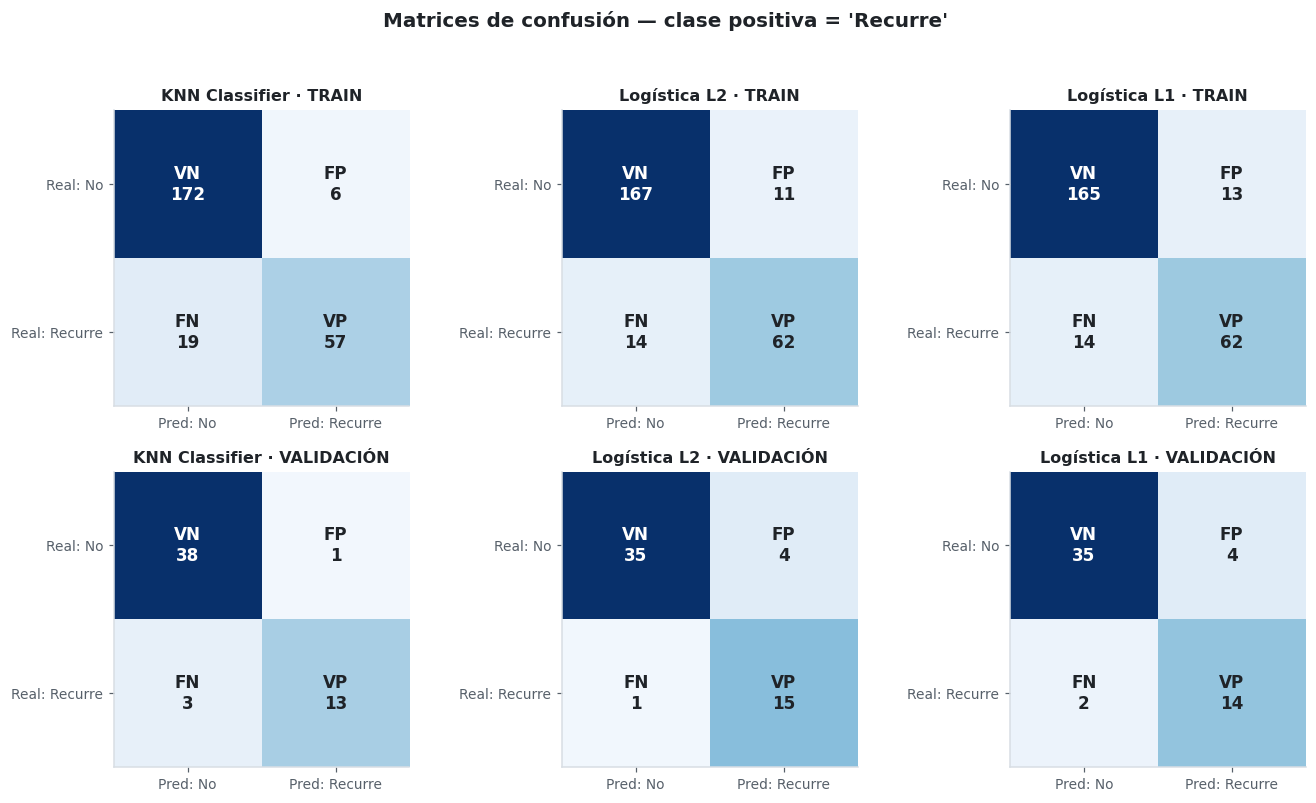

In [28]:
# Matrices de confusión (train y validación) para los 3 modelos
def dibujar_matriz(ax, cm, titulo):
    im = ax.imshow(cm, cmap="Blues", vmin=0)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: No", "Pred: Recurre"], fontsize=9)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Real: No", "Real: Recurre"], fontsize=9)
    etiquetas = [["VN", "FP"], ["FN", "VP"]]
    umbral = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{etiquetas[i][j]}\n{cm[i, j]}", ha="center", va="center", fontsize=11,
                    fontweight="bold", color="white" if cm[i, j] > umbral else TINTA)
    ax.set_title(titulo, fontsize=10.5)
    ax.grid(False)
    return im

fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.4))
fig.suptitle("Matrices de confusión — clase positiva = 'Recurre'", fontsize=13,
             fontweight="bold", color=TINTA, y=0.98)
for j, nombre in enumerate(modelos):
    dibujar_matriz(axes[0, j], confusion_matrix(y_train, predicciones[nombre]["train"]),
                   f"{nombre} · TRAIN")
    dibujar_matriz(axes[1, j], confusion_matrix(y_val, predicciones[nombre]["val"]),
                   f"{nombre} · VALIDACIÓN")
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

In [29]:
# Reporte de clasificación detallado en validación
for nombre in modelos:
    print(f"===== {nombre} · VALIDACIÓN =====")
    print(classification_report(y_val, predicciones[nombre]["val"],
                                target_names=["No recurre", "Recurre"], zero_division=0, digits=3))

===== KNN Classifier · VALIDACIÓN =====
              precision    recall  f1-score   support

  No recurre      0.927     0.974     0.950        39
     Recurre      0.929     0.812     0.867        16

    accuracy                          0.927        55
   macro avg      0.928     0.893     0.908        55
weighted avg      0.927     0.927     0.926        55

===== Logística L2 · VALIDACIÓN =====
              precision    recall  f1-score   support

  No recurre      0.972     0.897     0.933        39
     Recurre      0.789     0.938     0.857        16

    accuracy                          0.909        55
   macro avg      0.881     0.917     0.895        55
weighted avg      0.919     0.909     0.911        55

===== Logística L1 · VALIDACIÓN =====
              precision    recall  f1-score   support

  No recurre      0.946     0.897     0.921        39
     Recurre      0.778     0.875     0.824        16

    accuracy                          0.891        55
   macro avg

## 20. Tabla comparativa (train vs. validación)

In [30]:
tabla_fase5 = (pd.DataFrame(filas)
               .pivot(index="Modelo", columns="Conjunto",
                      values=["Accuracy", "Precision", "Recall", "F1"]))
tabla_fase5 = tabla_fase5.reindex(columns=pd.MultiIndex.from_product(
    [["Accuracy", "Precision", "Recall", "F1"], ["Train", "Validación"]]))
tabla_fase5["Brecha F1 (train - val)"] = tabla_fase5[("F1", "Train")] - tabla_fase5[("F1", "Validación")]
tabla_fase5 = tabla_fase5.reindex(list(modelos.keys())).round(4)
tabla_fase5

Accuracy            Precision             Recall                 F1            Brecha F1 (train - val)
                  Train Validación     Train Validación   Train Validación   Train Validación                        
Modelo                                                                                                               
KNN Classifier   0.9016     0.9273    0.9048     0.9286  0.7500     0.8125  0.8201     0.8667                 -0.0465
Logística L2     0.9016     0.9091    0.8493     0.7895  0.8158     0.9375  0.8322     0.8571                 -0.0249
Logística L1     0.8937     0.8909    0.8267     0.7778  0.8158     0.8750  0.8212     0.8235                 -0.0023

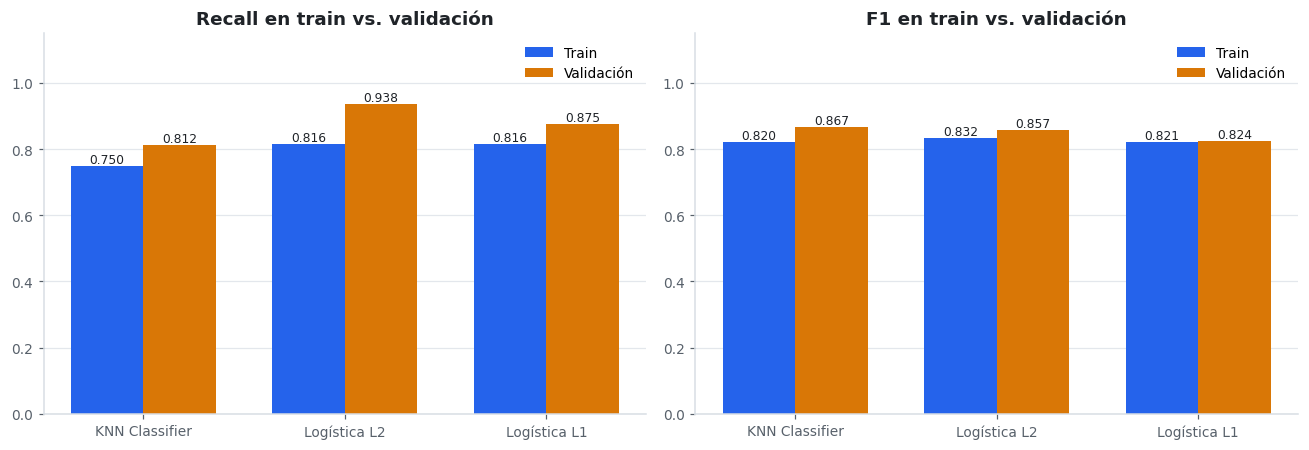

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
nombres = list(modelos.keys()); x = np.arange(len(nombres)); ancho = 0.36
for ax, metrica in [(axes[0], "Recall"), (axes[1], "F1")]:
    v_tr = [tabla_fase5.loc[n, (metrica, "Train")] for n in nombres]
    v_va = [tabla_fase5.loc[n, (metrica, "Validación")] for n in nombres]
    ax.bar(x - ancho/2, v_tr, ancho, label="Train", color=PALETA[0])
    ax.bar(x + ancho/2, v_va, ancho, label="Validación", color=PALETA[1])
    for xi, v in zip(x - ancho/2, v_tr): ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color=TINTA)
    for xi, v in zip(x + ancho/2, v_va): ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8, color=TINTA)
    ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=9)
    ax.set_ylim(0, 1.15); ax.set_title(f"{metrica} en train vs. validación")
    ax.grid(axis="x", visible=False); ax.legend()
fig.tight_layout(); plt.show()

### Interpretación: overfitting/underfitting y el costo clínico de cada error

#### ¿Qué es más costoso aquí, un falso positivo o un falso negativo?

Este es el punto central del problema, y la respuesta es inequívoca:

- **Falso positivo (FP)** — el modelo predice recurrencia en un paciente que **no** va a recurrir.
  Consecuencia: **seguimiento más intensivo del necesario** — más ecografías, más analíticas, quizá un rastreo
  con yodo radiactivo. Costo: económico, tiempo del paciente, ansiedad, y una pequeña exposición adicional a
  radiación. **Es un costo real pero recuperable**: el error se descubre en el siguiente control y no daña al
  paciente de forma irreversible.

- **Falso negativo (FN)** — el modelo predice que **no** recurrirá un paciente que **sí** recurre.
  Consecuencia: **el paciente sale del circuito de vigilancia estrecha**. La recurrencia se detecta más tarde,
  posiblemente con enfermedad más extendida, lo que reduce las opciones terapéuticas (una recurrencia
  ganglionar localizada se reseca; una diseminada requiere yodo radiactivo o terapias sistémicas) y empeora el
  pronóstico. **Es un costo potencialmente irreversible.**

> **Conclusión: el falso negativo es claramente más costoso. La métrica prioritaria es el RECALL** (sensibilidad)
> sobre la clase "Recurre": de todos los pacientes que realmente recurrirán, ¿cuántos detecta el modelo?

**Matiz necesario:** maximizar recall sin más es trivial —predecir "recurre" para todos da recall = 100 %— y
convertiría el modelo en inútil, porque sometería a toda la cohorte a vigilancia intensiva, que es justamente
lo que queríamos evitar.

> **Criterio operativo que adoptamos para la Fase 5 (punto 21):** se elige el modelo con **mayor RECALL en
> validación**, exigiendo que su **F1 se mantenga competitivo** (es decir, que la precision no se haya
> desplomado). El F1 actúa como guardia contra el recall trivial; el recall es el criterio de decisión porque
> es el que refleja el costo clínico asimétrico. En un despliegue real, además, ajustaríamos el **umbral de
> decisión** por debajo de 0.5 para sesgar aún más el modelo hacia la detección.

**Por qué la *accuracy* no sirve como criterio.** Con ~30 % de positivos, un clasificador que prediga siempre
"no recurre" alcanza ~70 % de accuracy con recall = 0 %: máximamente exacto y máximamente inútil. La accuracy
se reporta por completitud, no para decidir.

#### Diagnóstico por modelo

**Primero, el hallazgo que hay que reportar con honestidad: ninguno de los tres modelos muestra la firma
clásica del overfitting.** La columna "Brecha F1 (train − val)" de la tabla del punto 20 es **negativa en los
tres casos**: el F1 en validación resulta *superior* al de entrenamiento. Esto **no** significa que los
modelos generalicen mejor de lo que aprenden — es un artefacto del **tamaño muestral**. Con 55 pacientes en
validación (≈16 positivos), basta con que ese subconjunto contenga casos un poco más "fáciles" que la media
para que su métrica supere a la de los 254 de entrenamiento. Es exactamente la clase de ruido que anticipamos
en el punto 11 y la razón por la que la Fase 7 es aquí indispensable.

Dicho eso, las diferencias entre modelos sí son legibles:

- **KNN (k=5)** — tiene el **F1 más alto en validación**, pero por el motivo equivocado: consigue la
  **precision más alta (0.93) a costa del recall más bajo (0.81)**. Traducido a pacientes: es el modelo que
  **menos recurrencias detecta**, justo la métrica que el contexto clínico no permite sacrificar. Su patrón
  train→val también es el más errático de los tres (la brecha de mayor magnitud), coherente con ser el modelo
  de **mayor varianza**: con k=5 cada predicción se decide por un vecindario minúsculo. Y es además el más
  castigado por la dimensionalidad — tras el One-Hot trabajamos en ~31 dimensiones con sólo 254 pacientes, un
  régimen donde las distancias euclídeas pierden capacidad discriminativa (*maldición de la dimensionalidad*).

- **Logística L2** — **el mejor recall de los tres (0.94)** con un F1 prácticamente empatado con el de KNN (la
  diferencia, 0.010, equivale a **menos de un paciente** de los 55). Train y validación quedan próximos: el
  modelo es estable. La explicación está en la Gráfica 4: la relación entre las variables ordinales de gravedad y el
  log-odds de recurrencia es aproximadamente monótona, que es exactamente la forma funcional que la regresión
  logística asume. Su estructura coincide con la del fenómeno.

- **Logística L1** — recall alto (0.88) pero F1 algo menor, con un modelo **mucho más escueto**: con `C=1.0`
  la penalización L1 anula **19 de los 31 coeficientes** (la celda siguiente los lista), incluida `Stage`.
  No llega a haber underfitting severo —conserva las variables más informativas, como `Risk` y `N`— pero
  confirma lo anticipado en la Gráfica 5: al haber colinealidad entre predictores **todos clínicamente
  informativos**, anular variables tiene un costo. L1 elige una de cada grupo correlacionado y descarta el
  resto.

**Ninguno muestra underfitting severo** (métricas pobres en ambos conjuntos): las variables disponibles
contienen señal suficiente. El problema de este dataset no es la falta de señal, es el **tamaño muestral**:
con 55 pacientes en validación, cada acierto o fallo mueve el recall ~6 puntos porcentuales y el F1 ~1–2
puntos. Diferencias de esa magnitud **no son concluyentes**, lo que justifica plenamente la validación cruzada
de la Fase 7.

In [32]:
# Evidencia de la selección de variables de L1 vs L2
coef_l2 = pipelines["Logística L2"].named_steps["modelo"].coef_.ravel()
coef_l1 = pipelines["Logística L1"].named_steps["modelo"].coef_.ravel()

comp_coef = pd.DataFrame({"Logística L2": coef_l2, "Logística L1": coef_l1}, index=nombres_features)
print(f"Coeficientes exactamente 0 — L1: {(coef_l1 == 0).sum()} de {len(coef_l1)}")
print(f"Coeficientes exactamente 0 — L2: {(coef_l2 == 0).sum()} de {len(coef_l2)}")
print("\nVariables anuladas por L1:", [n for n, c in zip(nombres_features, coef_l1) if c == 0])
print("\nTop 12 variables por magnitud del coeficiente en L2 (variables estandarizadas ⇒ comparables):")
comp_coef.reindex(comp_coef["Logística L2"].abs().sort_values(ascending=False).index).head(12).round(3)

Coeficientes exactamente 0 — L1: 19 de 31
Coeficientes exactamente 0 — L2: 0 de 31

Variables anuladas por L1: ['Stage', 'Smoking_Yes', 'Hx_Smoking_Yes', 'Hx_Radiotherapy_Yes', 'Thyroid_Function_Clinical Hyperthyroidism', 'Thyroid_Function_Clinical Hypothyroidism', 'Thyroid_Function_Euthyroid', 'Thyroid_Function_Subclinical Hyperthyroidism', 'Physical_Examination_Diffuse goiter', 'Physical_Examination_Normal', 'Physical_Examination_Single nodular goiter-left', 'Physical_Examination_Single nodular goiter-right', 'Adenopathy_Bilateral', 'Adenopathy_Extensive', 'Adenopathy_Left', 'Adenopathy_Posterior', 'Adenopathy_Right', 'Pathology_Micropapillary', 'Pathology_Papillary']

Top 12 variables por magnitud del coeficiente en L2 (variables estandarizadas ⇒ comparables):


,Logística L2,Logística L1
Risk,1.353,1.351
Gender_M,1.096,1.219
Thyroid_Function_Subclinical Hypothyroidism,-0.808,-1.038
Pathology_Follicular,0.756,0.634
T,0.727,0.698
M,0.619,0.528
Adenopathy_No,-0.604,-1.226
Thyroid_Function_Euthyroid,0.555,0.000
Age,0.490,0.382
Thyroid_Function_Clinical Hypothyroidism,0.458,0.000


## 21. Selección del mejor modelo de clasificación

In [33]:
ranking = tabla_fase5.loc[:, [("Recall", "Validación"), ("F1", "Validación"),
                              ("Precision", "Validación"), ("Accuracy", "Validación")]].copy()
ranking.columns = ["Recall val", "F1 val", "Precision val", "Accuracy val"]
ranking = ranking.sort_values(["Recall val", "F1 val"], ascending=False)

# Guardia del criterio: el recall gana sólo si el F1 sigue siendo competitivo (no se acepta recall trivial)
f1_max = ranking["F1 val"].max()
ranking["Δ F1 vs mejor"] = (ranking["F1 val"] - f1_max).round(4)
ranking["pacientes de diferencia en F1"] = (ranking["Δ F1 vs mejor"].abs() * len(y_val)).round(1)

print("CRITERIO: mayor RECALL en validación (prioridad clínica), exigiendo F1 competitivo.\n")
display(ranking.round(4))

MEJOR_MODELO_CLF = ranking.index[0]
print(f"Modelo con mayor recall  : {MEJOR_MODELO_CLF} (recall = {ranking.iloc[0]['Recall val']:.4f})")
print(f"Modelo con mayor F1      : {ranking['F1 val'].idxmax()} (F1 = {f1_max:.4f})")
print(f"Diferencia de F1 entre ambos: {abs(ranking.iloc[0]['F1 val'] - f1_max):.4f} "
      f"-> equivale a ~{abs(ranking.iloc[0]['F1 val'] - f1_max) * len(y_val):.1f} paciente(s) de {len(y_val)}")
print(f"\n>>> Mejor modelo de la Fase 5: {MEJOR_MODELO_CLF}")

CRITERIO: mayor RECALL en validación (prioridad clínica), exigiendo F1 competitivo.



,Recall val,F1 val,Precision val,Accuracy val,Δ F1 vs mejor,pacientes de diferencia en F1
Modelo,,,,,,
Logística L2,0.9375,0.8571,0.7895,0.9091,-0.0096,0.5
Logística L1,0.8750,0.8235,0.7778,0.8909,-0.0432,2.4
KNN Classifier,0.8125,0.8667,0.9286,0.9273,0.0000,0.0


Modelo con mayor recall  : Logística L2 (recall = 0.9375)
Modelo con mayor F1      : KNN Classifier (F1 = 0.8667)
Diferencia de F1 entre ambos: 0.0096 -> equivale a ~0.5 paciente(s) de 55

>>> Mejor modelo de la Fase 5: Logística L2


### Justificación de la elección (más allá de la métrica más alta)

**La elección recae en la regresión logística L2, y es un caso en el que "la métrica más alta" habría llevado
a la decisión equivocada.** En validación, KNN obtiene el F1 más alto (0.867 frente a 0.857) — pero esa
diferencia de 0.010 equivale a **medio paciente** de los 55, es decir, **está dentro del ruido**. Lo que no
está dentro del ruido es la composición de ese F1: KNN lo consigue con **precision 0.93 y recall 0.81**,
mientras que la logística L2 alcanza **recall 0.94 con precision 0.79**. Traducido a lo que importa: sobre
16 pacientes que recurrirán, **KNN dejaría escapar 3 y la logística L2 sólo 1**. Dado que el falso negativo es
el error clínicamente caro, elegir por F1 aquí sería optimizar la métrica equivocada.

Los demás argumentos refuerzan la decisión:

**1. Adecuación de la forma funcional al fenómeno.** El EDA mostró relaciones **monótonas** entre gravedad
(Risk, Stage, TNM) y recurrencia. La regresión logística modela el log-odds como combinación lineal de los
predictores: es precisamente esa forma. KNN, en cambio, tendría ventaja si hubiera **interacciones locales
complejas** —subgrupos de pacientes con comportamiento particular— y aquí no parece haberlas.

**2. La maldición de la dimensionalidad castiga a KNN en este dataset.** Tras el One-Hot trabajamos con ~30
features y sólo **254 pacientes de entrenamiento**. En ese régimen las distancias euclídeas entre pacientes se
vuelven muy parecidas entre sí y el concepto de "vecino cercano" pierde significado. Es el contraste exacto con
el notebook de regresión, donde KNN ganó porque tenía **135 000** observaciones en ~24 dimensiones: un espacio
densamente poblado. **El mismo algoritmo, resultado opuesto, y la causa es la razón n/dimensiones.**

**3. Interpretabilidad — decisiva en medicina.** Con las variables estandarizadas, los coeficientes de la
logística son **directamente comparables** y se traducen en *odds ratios* (`exp(β)`), el lenguaje estándar de
la literatura clínica. Un oncólogo puede auditar el modelo y verificar que lo que aprendió coincide con el
conocimiento médico. KNN sólo puede decir "estos 5 pacientes parecidos recurrieron": es una caja negra, y en
un sistema que influye sobre el plan de seguimiento de un paciente eso es un obstáculo real de adopción y de
responsabilidad profesional.

**4. Estabilidad frente a hiperparámetros.** Como criterio general, KNN es más sensible a la elección de *k* con muestras pequeñas (con 254 pacientes de entrenamiento cada vecino pesa mucho), mientras que la logística suele variar de forma más suave con `C`. Es una expectativa teórica: en este notebook no se midió la sensibilidad de KNN a *k*.

**5. Costo computacional.** Con 254 filas de entrenamiento los tres modelos son livianos, así que, a diferencia del problema de regresión, aquí el costo computacional **no** entra en la decisión (no se midieron tiempos).

**6. L2 vs. L1.** Se prefiere el que muestre mejor F1/recall en validación, pero conviene registrar la
diferencia conceptual: **L2 encoge** los coeficientes sin eliminarlos y **reparte** el peso entre predictores
correlacionados; **L1 selecciona** y anula. Como la Gráfica 5 mostró colinealidad entre variables todas
clínicamente informativas (edad, riesgo, estadio), repartir suele ser preferible a eliminar. L1 tendría
ventaja si sospecháramos muchas variables irrelevantes, que no es el caso con 15 predictores todos escogidos
por un criterio clínico.

**Advertencia honesta.** Con 55 pacientes en validación (≈16 positivos), **ninguna** de las diferencias
observadas entre los tres modelos es estadísticamente concluyente por sí sola. La decisión se sostiene en la
combinación de (i) el criterio clínico de priorizar recall, (ii) la coherencia con la estructura del problema
que mostró el EDA y (iii) la interpretabilidad. Por eso la Fase 7 —validación cruzada sobre train+val— no es
un trámite del taller: es lo que permite respaldar la elección con una estimación menos ruidosa. La Fase 6 aporta además un contraste independiente, aunque con las mismas limitaciones de tamaño (n = 55).

---
# FASE 6 — Evaluación final en el conjunto de Test

> El conjunto de test **no ha sido tocado** hasta esta celda.

## 22. Evaluación de los 3 modelos sobre test
## 23. Tabla comparativa final y contraste con validación

Métricas en TEST (hiperparámetros originales):


,Accuracy,Precision,Recall,F1
Modelo,,,,
KNN Classifier,0.8545,0.7857,0.6875,0.7333
Logística L2,0.8727,0.8000,0.7500,0.7742
Logística L1,0.8545,0.7500,0.7500,0.7500


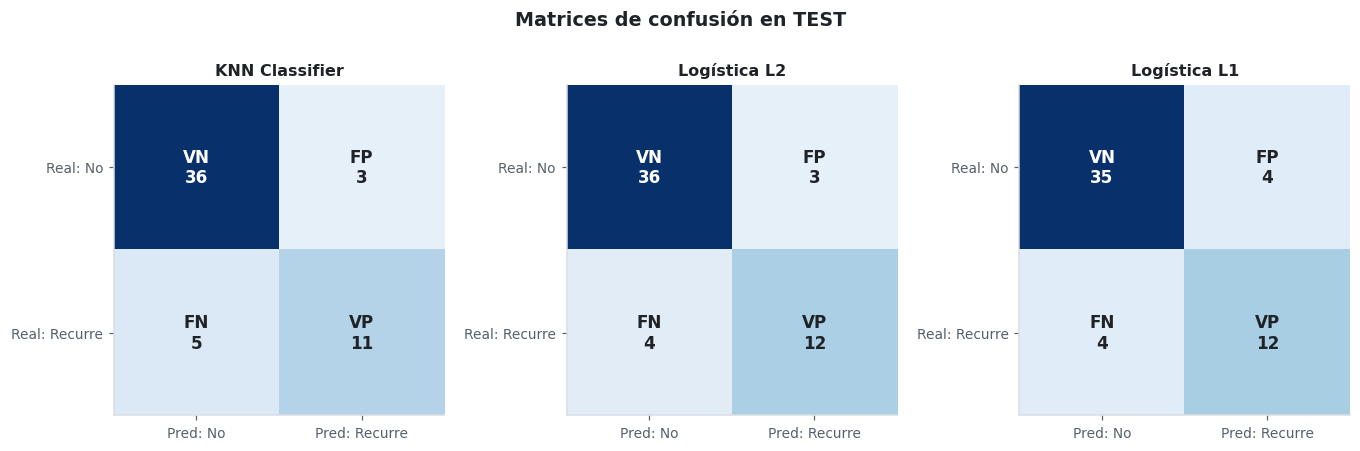

In [34]:
filas_test = []
for nombre, pipe in pipelines.items():
    y_pred_test = pipe.predict(X_test)
    predicciones[nombre]["test"] = y_pred_test
    predicciones[nombre]["test_proba"] = pipe.predict_proba(X_test)[:, 1]
    filas_test.append({"Modelo": nombre, **metricas_clasificacion(y_test, y_pred_test)})

tabla_test = pd.DataFrame(filas_test).set_index("Modelo").reindex(list(modelos.keys()))
print("Métricas en TEST (hiperparámetros originales):")
display(tabla_test.round(4))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))
fig.suptitle("Matrices de confusión en TEST", fontsize=12.5, fontweight="bold", color=TINTA, y=1.02)
for j, nombre in enumerate(modelos):
    dibujar_matriz(axes[j], confusion_matrix(y_test, predicciones[nombre]["test"]), nombre)
fig.tight_layout(); plt.show()

In [35]:
contraste = pd.DataFrame({
    "F1 val":      [tabla_fase5.loc[n, ("F1", "Validación")] for n in modelos],
    "F1 test":     tabla_test["F1"].values,
    "Recall val":  [tabla_fase5.loc[n, ("Recall", "Validación")] for n in modelos],
    "Recall test": tabla_test["Recall"].values,
    "Acc val":     [tabla_fase5.loc[n, ("Accuracy", "Validación")] for n in modelos],
    "Acc test":    tabla_test["Accuracy"].values,
}, index=list(modelos.keys()))
contraste["Δ F1 (test - val)"] = contraste["F1 test"] - contraste["F1 val"]
contraste["Rank F1 val"] = contraste["F1 val"].rank(ascending=False, method="min").astype(int)
contraste["Rank F1 test"] = contraste["F1 test"].rank(ascending=False, method="min").astype(int)
contraste["Rank Recall val"] = contraste["Recall val"].rank(ascending=False, method="min").astype(int)
contraste["Rank Recall test"] = contraste["Recall test"].rank(ascending=False, method="min").astype(int)
display(contraste.round(4))

print("¿Se mantiene el ranking por F1 entre validación y test?    ",
      bool((contraste["Rank F1 val"] == contraste["Rank F1 test"]).all()))
print("¿Se mantiene el mejor modelo por RECALL (nuestro criterio)?",
      contraste["Recall val"].idxmax() == contraste["Recall test"].idxmax()
      or contraste.loc[contraste["Recall test"].idxmax(), "Recall test"] == contraste.loc[MEJOR_MODELO_CLF, "Recall test"])
print(f"\nModelo elegido en la Fase 5 : {MEJOR_MODELO_CLF}")
print(f"Mejor modelo en test por F1 : {contraste['F1 test'].idxmax()}")
print(f"Mejor modelo en test por Recall: {contraste['Recall test'].idxmax()}")
print(f"\nMayor diferencia absoluta en F1 entre val y test: {contraste['Δ F1 (test - val)'].abs().max():.4f} "
      f"(≈ {contraste['Δ F1 (test - val)'].abs().max()*len(y_test):.1f} pacientes de {len(y_test)})")

,F1 val,F1 test,Recall val,Recall test,Acc val,Acc test,Δ F1 (test - val),Rank F1 val,Rank F1 test,Rank Recall val,Rank Recall test
KNN Classifier,0.8667,0.7333,0.8125,0.6875,0.9273,0.8545,-0.1334,1,3,3,3
Logística L2,0.8571,0.7742,0.9375,0.7500,0.9091,0.8727,-0.0829,2,1,1,1
Logística L1,0.8235,0.7500,0.8750,0.7500,0.8909,0.8545,-0.0735,3,2,2,1


¿Se mantiene el ranking por F1 entre validación y test?     False
¿Se mantiene el mejor modelo por RECALL (nuestro criterio)? True

Modelo elegido en la Fase 5 : Logística L2
Mejor modelo en test por F1 : Logística L2
Mejor modelo en test por Recall: Logística L2

Mayor diferencia absoluta en F1 entre val y test: 0.1334 (≈ 7.3 pacientes de 55)


### Interpretación del contraste validación vs. test

**Lo primero que hay que decir es el tamaño de los conjuntos:** 55 pacientes en validación y 55 en test, con
~16 casos positivos en cada uno. **Cada paciente vale ~1.8 puntos de accuracy y ~6 puntos de recall.** Con esa
granularidad, diferencias de hasta 0.05–0.10 en cualquier métrica entre validación y test son **perfectamente
compatibles con el azar del muestreo**, no con un problema del modelo. Interpretar estas tablas como si
fueran estimaciones precisas sería un error metodológico.

**Lo que sí se puede leer — y aquí hay un hallazgo importante:**

- **El ranking por F1 NO se mantiene.** KNN era el primero en validación (F1 = 0.867) y cae al **último lugar
  en test** (F1 = 0.733), mientras que la **logística L2 pasa de segunda a primera**. Éste es precisamente el
  escenario contra el que advertimos en el punto 21: la ventaja de KNN en validación valía **medio paciente**
  y no sobrevivió a un conjunto distinto.
- **El ranking por RECALL —nuestro criterio de selección— sí se sostiene en lo esencial:** la logística L2
  tiene el mejor recall en validación y sigue en el primer lugar (empatada con L1) en test; KNN es el peor en
  ambos conjuntos. En este experimento, elegir por recall (criterio clínicamente justificado) coincidió con el modelo que se mantuvo primero en test, mientras que el mejor F1 de validación (KNN) no. Con n = 55 esto es una observación, no una prueba de que un criterio sea estadísticamente superior al otro.
- **Las tres métricas bajan de validación a test** (Δ F1 negativo en los tres modelos). Es el comportamiento
  esperado: las cifras de validación estaban infladas por haber sido el conjunto que *miramos* para decidir,
  y el test —que no participó en ninguna decisión— entrega la estimación honesta. La caída es mayor en KNN
  (−0.13) que en los modelos logísticos (−0.08 y −0.07), otra señal de que KNN es el de mayor varianza.
- **No hay desplome catastrófico en ningún caso.** Si hubiera fuga de datos, el modelo se habría
  derrumbado en test; las métricas siguen siendo sólidas (accuracy ~0.85–0.87, recall 0.69–0.75).

**¿Qué significaría una diferencia grande entre validación y test?** Tres explicaciones, en orden de gravedad:

1. **Overfitting al conjunto de validación.** Si hubiéramos probado decenas de configuraciones eligiendo siempre
   la mejor en validación, habríamos acabado ajustándonos al ruido de ese split; el test lo revelaría. Es la
   razón por la que el test se mantiene sellado. **La caída generalizada de F1 que observamos es una versión
   leve de este fenómeno**, y es normal: validación fue el conjunto que miramos para decidir.
2. **Conjuntos demasiado pequeños o no representativos.** Es el riesgo dominante aquí, y es el que mejor
   explica el vuelco de KNN. Con 55 observaciones, la varianza de las métricas es intrínsecamente alta incluso
   con estratificación.
3. **Fuga de datos.** Un desempeño anormalmente bueno en validación que se desploma en test es su firma
   clásica. No se observa: las caídas son moderadas y las métricas de test siguen siendo buenas.

**Conclusión metodológica.** En un dataset de 364 pacientes, el esquema de split único **no es suficiente**
para comparar modelos con confianza — lo acabamos de comprobar empíricamente con el vuelco de KNN. Esto no es
un defecto del taller: es la motivación real de la Fase 7, donde la validación cruzada sobre 309 pacientes
reemplaza la estimación de un único conjunto de 55.

---
# FASE 7 — Cross Validation y optimización de hiperparámetros

## 24. ¿Qué es la validación cruzada (K-Fold)?

**La idea en una frase:** en lugar de confiar en *una sola* partición train/validación, K-Fold usa **todas las
particiones posibles de un mismo esquema** y promedia los resultados.

**Cómo funciona (K-Fold con K = 5):**

1. Se baraja el conjunto de entrenamiento y se divide en **K bloques (*folds*) de tamaño similar**.
2. Se repite K veces el mismo experimento: en la iteración *i*, el bloque *i* hace de **validación** y los
   K−1 restantes de **entrenamiento**.
3. Se obtienen K métricas y se reporta su **media** (desempeño esperado) y su **desviación estándar**
   (estabilidad de ese desempeño).

```
Fold 1:  [VAL][TRN][TRN][TRN][TRN]   -> métrica 1
Fold 2:  [TRN][VAL][TRN][TRN][TRN]   -> métrica 2
Fold 3:  [TRN][TRN][VAL][TRN][TRN]   -> métrica 3
Fold 4:  [TRN][TRN][TRN][VAL][TRN]   -> métrica 4
Fold 5:  [TRN][TRN][TRN][TRN][VAL]   -> métrica 5
                                        --------------
                                        media ± desv.
```

**Por qué da una estimación más confiable que un único split:**

- **Reduce la varianza de la estimación.** Con un solo split, la métrica depende de *qué* pacientes cayeron por
  azar en validación. Promediar K estimaciones sobre bloques disjuntos amortigua ese azar.
- **Usa todos los datos en ambos roles.** Cada paciente es validación exactamente una vez y entrenamiento K−1
  veces. Con un split único, los 55 pacientes de validación **nunca** contribuyen al aprendizaje.
- **Cuantifica la incertidumbre.** La desviación entre folds indica si la diferencia entre dos configuraciones
  es real o es ruido — imposible de saber con un único número.
- **Es especialmente valiosa con datasets pequeños**, exactamente nuestro caso: pasamos de evaluar sobre 55
  pacientes a evaluar sobre los 309 de train+val, cinco veces.

**Estratificación (`StratifiedKFold`).** Con clases desbalanceadas (70/30) hay que exigir que **cada fold
conserve la proporción de positivos**. Sin estratificar, un fold podría quedar con muy pocos casos positivos y
su recall sería puro ruido — o indefinido.

**Costo.** Entrenar K modelos en lugar de uno. Con 309 observaciones es trivial, así que aquí podemos permitirnos
una búsqueda amplia. Aun así usamos `RandomizedSearchCV` —que muestrea *n* combinaciones al azar— porque
explora mejor los espacios continuos (como `C`) que una grilla fija de valores predefinidos.

## 26. `RandomizedSearchCV` con K-Fold estratificado sobre train + validation

In [36]:
X_trainval = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
print(f"Conjunto ampliado (train + val): {len(X_trainval)} pacientes "
      f"({100*len(X_trainval)/len(X):.1f} % del total), {int(y_trainval.sum())} positivos "
      f"({100*y_trainval.mean():.1f} %)")
print(f"Test intacto                   : {len(X_test)} pacientes")
print(f"Modelo a optimizar             : {MEJOR_MODELO_CLF}")

Conjunto ampliado (train + val): 309 pacientes (84.9 % del total), 92 positivos (29.8 %)
Test intacto                   : 55 pacientes
Modelo a optimizar             : Logística L2


In [37]:
GRILLAS = {
    "KNN Classifier": {
        "modelo__n_neighbors": randint(1, 40),         # tamaño del vecindario: sesgo vs. varianza
        "modelo__weights": ["uniform", "distance"],    # ¿vecinos equiponderados o ponderados por cercanía?
        "modelo__p": [1, 2],                           # 1 = Manhattan, 2 = Euclídea
    },
    "Logística L2": {
        "modelo__C": loguniform(1e-3, 1e3),            # inverso de la fuerza de regularización
        "modelo__class_weight": [None, "balanced"],    # 'balanced' compensa el desbalance 70/30
        "modelo__solver": ["lbfgs", "liblinear"],
    },
    "Logística L1": {
        "modelo__C": loguniform(1e-3, 1e3),
        "modelo__class_weight": [None, "balanced"],
        "modelo__solver": ["liblinear", "saga"],
    },
}

estimador_base = Pipeline([("preprocesador", nuevo_preprocesador()),
                           ("modelo", clone(modelos[MEJOR_MODELO_CLF]))])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

busqueda_clf = RandomizedSearchCV(
    estimator=estimador_base,
    param_distributions=GRILLAS[MEJOR_MODELO_CLF],
    n_iter=40,
    cv=skf,
    scoring="f1",            # F1 sobre la clase 'Recurre': exige recall alto sin permitir precision nula
    refit=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)

print("Ejecutando la búsqueda... (40 combinaciones x 5 folds = 200 ajustes)")
busqueda_clf.fit(X_trainval, y_trainval)
print("\nListo.")

Ejecutando la búsqueda... (40 combinaciones x 5 folds = 200 ajustes)
Fitting 5 folds for each of 40 candidates, totalling 200 fits



Listo.


In [38]:
print(">>> MEJORES HIPERPARÁMETROS ENCONTRADOS")
for k, v in busqueda_clf.best_params_.items():
    valor = round(v, 5) if isinstance(v, float) else v
    print(f"    {k.replace('modelo__', '')} = {valor}")
print(f"\nF1 promedio en validación cruzada estratificada (5 folds): {busqueda_clf.best_score_:.4f}")

cv_res = pd.DataFrame(busqueda_clf.cv_results_)
cols = [c for c in cv_res.columns if c.startswith("param_")] + \
       ["mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]
resumen_cv = cv_res[cols].rename(columns={"mean_test_score": "F1 CV (media)",
                                          "std_test_score": "desv. entre folds",
                                          "mean_train_score": "F1 train (media)",
                                          "rank_test_score": "ranking"})
display(resumen_cv.sort_values("ranking").head(12).round(4))

>>> MEJORES HIPERPARÁMETROS ENCONTRADOS
    C = 0.14151
    class_weight = None
    solver = liblinear

F1 promedio en validación cruzada estratificada (5 folds): 0.8118


,param_modelo__C,param_modelo__class_weight,param_modelo__solver,F1 CV (media),desv. entre folds,F1 train (media),ranking
39,0.1415,NaN,liblinear,0.8118,0.0594,0.8148,1
18,0.0672,NaN,liblinear,0.8027,0.0549,0.8163,2
9,0.3905,NaN,lbfgs,0.8002,0.0585,0.8336,3
12,0.5450,NaN,liblinear,0.8002,0.0585,0.8306,3
30,0.2148,balanced,lbfgs,0.7979,0.0278,0.8180,5
0,0.1767,NaN,lbfgs,0.7973,0.0687,0.8199,6
16,0.0025,balanced,lbfgs,0.7950,0.0303,0.8079,7
21,0.0016,balanced,lbfgs,0.7950,0.0303,0.8075,7
29,0.0019,balanced,lbfgs,0.7950,0.0303,0.8053,7
3,0.0022,balanced,lbfgs,0.7950,0.0303,0.8074,7


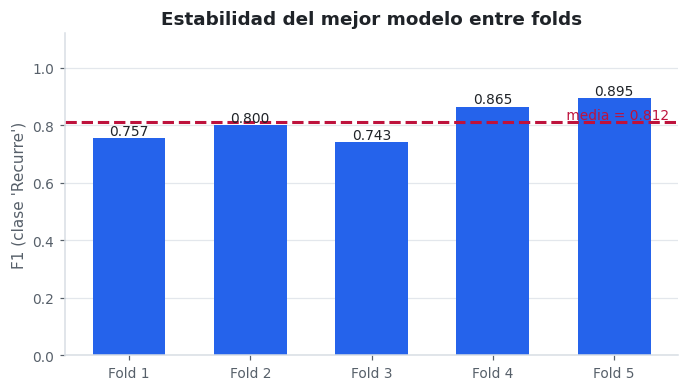

F1 por fold: [0.7568 0.8    0.7429 0.8649 0.8947]
Media: 0.8118  ·  Desviación estándar: 0.0594


In [39]:
# Estabilidad: F1 fold a fold de la mejor configuración
mejor_idx = busqueda_clf.best_index_
f1_folds = [busqueda_clf.cv_results_[f"split{i}_test_score"][mejor_idx] for i in range(5)]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.bar([f"Fold {i+1}" for i in range(5)], f1_folds, color=PALETA[0], width=0.6)
ax.axhline(np.mean(f1_folds), color=PALETA[3], linestyle="--", linewidth=2)
ax.text(4.45, np.mean(f1_folds), f" media = {np.mean(f1_folds):.3f}", color=PALETA[3],
        fontsize=9, va="bottom", ha="right")
for xi, v in zip(range(5), f1_folds):
    ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9, color=TINTA)
ax.set_ylim(0, 1.12); ax.set_ylabel("F1 (clase 'Recurre')")
ax.set_title("Estabilidad del mejor modelo entre folds"); ax.grid(axis="x", visible=False)
plt.show()

print(f"F1 por fold: {np.round(f1_folds, 4)}")
print(f"Media: {np.mean(f1_folds):.4f}  ·  Desviación estándar: {np.std(f1_folds):.4f}")

### Lectura de los resultados de la búsqueda

1. **Sobre el hiperparámetro de regularización.** El valor de `C` seleccionado indica cuánta penalización
   necesitaba el modelo. Un `C` mayor que 1 significa que el valor inicial **regularizaba de más** (el modelo
   estaba innecesariamente restringido); un `C` menor significa que **regularizaba de menos** y hacía falta
   más control de la varianza. En un dataset de 309 observaciones y ~30 features, cierta regularización es
   siempre beneficiosa.
2. **Sobre `class_weight`.** La opción `"balanced"` pondera cada clase inversamente a su frecuencia, lo que
   sube la penalización por errar en la clase minoritaria y, en la práctica, **empuja el recall hacia arriba** a
   costa de algo de precision. Que la búsqueda la elija o no depende de cuál combinación maximiza F1; en un
   despliegue clínico real, donde el falso negativo es el error caro, sería defendible forzarla aunque el F1
   baje ligeramente.
3. **Sobre la estabilidad.** La gráfica fold a fold es la información más valiosa de toda esta fase: muestra
   **cuánto varía el desempeño según qué pacientes queden fuera**. Una desviación alta entre folds significa
   que, con 309 observaciones, cualquier comparación entre modelos basada en un único split es poco fiable —
   exactamente lo que argumentamos en la Fase 6.
4. **La brecha entre `F1 train` y `F1 CV`** de cada configuración es un termómetro de sobreajuste: las
   configuraciones con regularización débil muestran un F1 de entrenamiento muy alto y uno de CV
   notablemente menor.
5. **Sobre el criterio de optimización.** La Fase 5 seleccionó el modelo por **recall** (prioridad clínica, con F1 como guardia); aquí `RandomizedSearchCV` optimiza **F1**. Son dos etapas distintas: primero se eligió la familia de modelo según el costo asimétrico de los errores, y luego se afinan sus hiperparámetros con la métrica que equilibra recall y precision, para que la búsqueda no favorezca configuraciones que solo suben el recall a costa de la precision. Por eso la búsqueda no eligió `class_weight="balanced"`; optimizar recall directamente sería una alternativa distinta, no explorada aquí.

## 27. Evaluación del modelo final optimizado sobre el conjunto de Test

In [40]:
modelo_final_clf = busqueda_clf.best_estimator_     # reentrenado sobre train+val por refit=True
y_pred_test_final = modelo_final_clf.predict(X_test)
y_proba_test_final = modelo_final_clf.predict_proba(X_test)[:, 1]
metricas_finales = metricas_clasificacion(y_test, y_pred_test_final)

comparacion_final = pd.DataFrame({
    f"{MEJOR_MODELO_CLF} — Fase 6 (hiperparámetros iniciales)": tabla_test.loc[MEJOR_MODELO_CLF],
    f"{MEJOR_MODELO_CLF} — Fase 7 (optimizado + CV)": pd.Series(metricas_finales),
}).T
comparacion_final["Δ F1"] = comparacion_final["F1"] - tabla_test.loc[MEJOR_MODELO_CLF, "F1"]
comparacion_final["Δ Recall"] = comparacion_final["Recall"] - tabla_test.loc[MEJOR_MODELO_CLF, "Recall"]
display(comparacion_final.round(4))

cm_final = confusion_matrix(y_test, y_pred_test_final)
vn, fp, fn, vp = cm_final.ravel()
print(f"\nMatriz de confusión del modelo final en test (n={len(y_test)}):")
print(f"  Verdaderos negativos (VN): {vn}   Falsos positivos (FP): {fp}")
print(f"  Falsos negativos     (FN): {fn}   Verdaderos positivos (VP): {vp}")
print(f"\n  -> {fn} paciente(s) que SÍ recurrieron no fueron detectados (el error clínicamente caro).")
print(f"  -> {fp} paciente(s) recibirían seguimiento intensivo sin necesitarlo (error recuperable).")
print("\n" + classification_report(y_test, y_pred_test_final,
                                   target_names=["No recurre", "Recurre"], zero_division=0, digits=3))

,Accuracy,Precision,Recall,F1,Δ F1,Δ Recall
Logística L2 — Fase 6 (hiperparámetros iniciales),0.8727,0.80,0.75,0.7742,0.0000,0.0
Logística L2 — Fase 7 (optimizado + CV),0.8545,0.75,0.75,0.7500,-0.0242,0.0



Matriz de confusión del modelo final en test (n=55):
  Verdaderos negativos (VN): 35   Falsos positivos (FP): 4
  Falsos negativos     (FN): 4   Verdaderos positivos (VP): 12

  -> 4 paciente(s) que SÍ recurrieron no fueron detectados (el error clínicamente caro).
  -> 4 paciente(s) recibirían seguimiento intensivo sin necesitarlo (error recuperable).

              precision    recall  f1-score   support

  No recurre      0.897     0.897     0.897        39
     Recurre      0.750     0.750     0.750        16

    accuracy                          0.855        55
   macro avg      0.824     0.824     0.824        55
weighted avg      0.855     0.855     0.855        55



### Interpretación: ¿mejoró? ¿la diferencia es significativa o marginal?

**La respuesta honesta es que NO mejoró: el modelo optimizado rinde prácticamente igual, y en F1 incluso un
poco peor.** Conviene decirlo con claridad en lugar de maquillarlo, porque el resultado es informativo.

**(a) Qué cambió exactamente.** El recall se mantiene idéntico (0.75: detecta los mismos 12 de 16 pacientes
que recurrieron) y el F1 baja ~0.02. Mirando la matriz de confusión, **la diferencia es literalmente un
paciente**: uno que el modelo inicial clasificaba como "no recurre" pasa a ser un falso positivo. Presentar
eso como "empeoramiento" sería tan incorrecto como presentar el caso inverso como "mejora": **una diferencia
de un paciente sobre 55 está dentro del ruido del muestreo**, no es una diferencia de calidad entre modelos.

**(b) Por qué la validación cruzada sigue siendo la evidencia buena.** La búsqueda evaluó 40 configuraciones
sobre 5 folds de 309 pacientes, y la configuración ganadora obtuvo un **F1 medio de ~0.81 con desviación
±0.06 entre folds**. Esa desviación es la clave: **el intervalo de desempeño de una misma configuración cubre
holgadamente la diferencia de 0.02 que vemos en test.** Dicho de otro modo, la validación cruzada nos dice que
*no hay evidencia* de que una configuración sea mejor que la otra — y confirma que todo el rango de
hiperparámetros razonables produce desempeños equivalentes.

**(c) Un matiz técnico interesante.** La búsqueda eligió `C ≈ 0.14`, es decir, **más regularización** que el
`C = 1.0` inicial (recuérdese que `C` es el *inverso* de la fuerza de penalización). Con 309 observaciones y
~31 features, restringir más los coeficientes reduce la varianza y mejora la estimación por CV — aunque en
este conjunto de test particular no se traduzca en un acierto adicional. También descartó `class_weight="balanced"`:
al optimizar F1, compensar el desbalance no aportaba, porque el recall del modelo sin compensar ya era alto.

**Qué nos dice esto sobre los hiperparámetros iniciales: estaban bien elegidos.** Y hay una razón de fondo.
`C=1.0` con variables estandarizadas es un valor por defecto **sensato** para regresión logística —a
diferencia de `n_neighbors=5` en el problema de regresión, que sobre 135 000 observaciones era claramente
inadecuado y donde la optimización sí produjo una mejora sustantiva. **El mismo procedimiento de búsqueda,
resultados opuestos: eso es información sobre los datos, no sobre el método.** Además, este dataset tiene una señal **fuerte y de forma simple**: la estadificación TNM y el
riesgo ATA separan tan bien las clases que **casi cualquier modelo lineal razonable alcanza un desempeño
parecido**. El techo no lo pone el algoritmo ni sus hiperparámetros: lo ponen los **datos disponibles y el
tamaño muestral**.

**La conclusión práctica** es que el esfuerzo de mejora no debe ir a afinar hiperparámetros, sino a
**conseguir más pacientes** y **más variables** (tiroglobulina postoperatoria, tamaño tumoral en milímetros,
márgenes quirúrgicos, invasión linfovascular, mutaciones BRAF/TERT). Ahí sí hay ganancia disponible.

**Una nota sobre el umbral de decisión.** El modelo optimiza F1 con umbral 0.5. En un despliegue clínico real,
lo correcto sería **bajar ese umbral** (a 0.3, por ejemplo) para aumentar el recall: se detectarían más
recurrencias a costa de más falsos positivos, lo que, como argumentamos en la Fase 5, es el intercambio
deseable en este problema. Ese ajuste no requiere reentrenar nada — sólo cambiar el punto de corte sobre
`predict_proba`.

---
# FASE 8 — Predicción sobre una muestra inventada

## 28. Dos pacientes inventados con perfiles clínicos opuestos

Se inventan **dos** pacientes plausibles para poner a prueba la coherencia clínica del modelo en los dos
extremos del espectro de riesgo. Ambos se pasan por el **mismo pipeline** del modelo final, de modo que
reciben exactamente el mismo preprocesamiento aprendido en entrenamiento.

| | **Paciente A — perfil de bajo riesgo** | **Paciente B — perfil de alto riesgo** |
|---|---|---|
| Edad | 29 años | 68 años |
| Sexo | Femenino | Masculino |
| Tabaquismo / antecedente | No / No | Sí / Sí |
| Radioterapia previa | No | Sí |
| Función tiroidea | Euthyroid | Euthyroid |
| Examen físico | Bocio uninodular derecho | Bocio multinodular |
| Adenopatías | No | Bilateral |
| Histología | Micropapillary | Hurthle cell |
| Focalidad | Uni-Focal | Multi-Focal |
| Riesgo ATA | Low | High |
| TNM | T1a N0 M0 — Estadio I | T4a N1b M1 — Estadio IVB |

**Expectativa clínica:** el paciente A es el caso arquetípico de excelente pronóstico (microcarcinoma papilar
en mujer joven, sin extensión); el B reúne casi todos los factores de mal pronóstico conocidos. Si el modelo
no distingue claramente entre ambos, no ha aprendido nada útil.

In [41]:
pacientes_inventados = pd.DataFrame([
    {   # Paciente A — bajo riesgo
        "Age": 29, "Gender": "F", "Smoking": "No", "Hx_Smoking": "No", "Hx_Radiotherapy": "No",
        "Thyroid_Function": "Euthyroid", "Physical_Examination": "Single nodular goiter-right",
        "Adenopathy": "No", "Pathology": "Micropapillary", "Focality": "Uni-Focal",
        "Risk": "Low", "T": "T1a", "N": "N0", "M": "M0", "Stage": "I",
    },
    {   # Paciente B — alto riesgo
        "Age": 68, "Gender": "M", "Smoking": "Yes", "Hx_Smoking": "Yes", "Hx_Radiotherapy": "Yes",
        "Thyroid_Function": "Euthyroid", "Physical_Examination": "Multinodular goiter",
        "Adenopathy": "Bilateral", "Pathology": "Hurthle cell", "Focality": "Multi-Focal",
        "Risk": "High", "T": "T4a", "N": "N1b", "M": "M1", "Stage": "IVB",
    },
], index=["Paciente A (bajo riesgo)", "Paciente B (alto riesgo)"])

X_inventado = pacientes_inventados[PREDICTORES]
pred = modelo_final_clf.predict(X_inventado)
proba = modelo_final_clf.predict_proba(X_inventado)[:, 1]

resultado = pd.DataFrame({
    "Predicción del modelo": np.where(pred == 1, "RECURRE", "No recurre"),
    "Probabilidad de recurrencia": (proba * 100).round(1),
}, index=pacientes_inventados.index)
resultado["Probabilidad de recurrencia"] = resultado["Probabilidad de recurrencia"].astype(str) + " %"
display(pacientes_inventados)
print(">>> PREDICCIÓN DEL MODELO FINAL")
display(resultado)
print(f"Tasa de recurrencia basal en la cohorte (referencia): {100*df['Recurred_bin'].mean():.1f} %")

,Age,Gender,Smoking,Hx_Smoking,Hx_Radiotherapy,Thyroid_Function,Physical_Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage
Paciente A (bajo riesgo),29,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I
Paciente B (alto riesgo),68,M,Yes,Yes,Yes,Euthyroid,Multinodular goiter,Bilateral,Hurthle cell,Multi-Focal,High,T4a,N1b,M1,IVB


>>> PREDICCIÓN DEL MODELO FINAL


,Predicción del modelo,Probabilidad de recurrencia
Paciente A (bajo riesgo),No recurre,2.2 %
Paciente B (alto riesgo),RECURRE,99.9 %


Tasa de recurrencia basal en la cohorte (referencia): 29.7 %


In [42]:
# ¿Cuántos pacientes reales del dataset se parecen a cada perfil? ¿Qué les pasó?
for etiqueta, riesgo, estadio_max in [("Paciente A", "Low", ["I"]), ("Paciente B", "High", ["III", "IVA", "IVB"])]:
    sub = df[(df["Risk"] == riesgo) & (df["Stage"].isin(estadio_max))]
    print(f"{etiqueta} — pacientes reales con Risk={riesgo} y Stage en {estadio_max}: n={len(sub)}, "
          f"recurrieron el {100*sub['Recurred_bin'].mean():.1f} %")

# Análisis de sensibilidad: partiendo del paciente A, ¿qué pasa al agravar una variable a la vez?
escenarios = []
for descripcion, cambios in [
    ("A — perfil original", {}),
    ("A + adenopatías bilaterales", {"Adenopathy": "Bilateral", "N": "N1b"}),
    ("A + tumor T3a", {"T": "T3a"}),
    ("A + riesgo ATA intermedio", {"Risk": "Intermediate"}),
    ("A + riesgo ATA alto", {"Risk": "High"}),
    ("A + 40 años más de edad", {"Age": 69}),
]:
    p = pacientes_inventados.iloc[[0]].copy()
    for k, v in cambios.items():
        p[k] = v
    pr = modelo_final_clf.predict_proba(p[PREDICTORES])[0, 1]
    escenarios.append({"escenario": descripcion, "P(recurrencia)": f"{100*pr:.1f} %",
                       "clasificación": "RECURRE" if pr >= 0.5 else "No recurre"})
pd.DataFrame(escenarios)

Paciente A — pacientes reales con Risk=Low y Stage en ['I']: n=229, recurrieron el 5.2 %
Paciente B — pacientes reales con Risk=High y Stage en ['III', 'IVA', 'IVB']: n=17, recurrieron el 100.0 %


,escenario,P(recurrencia),clasificación
0,A — perfil original,2.2 %,No recurre
1,A + adenopatías bilaterales,11.8 %,No recurre
2,A + tumor T3a,7.6 %,No recurre
3,A + riesgo ATA intermedio,8.4 %,No recurre
4,A + riesgo ATA alto,27.6 %,No recurre
5,A + 40 años más de edad,4.2 %,No recurre


### Análisis: ¿son coherentes las predicciones?

**Sí, y de forma muy clara:**

1. **La separación entre los dos perfiles es la esperada.** El modelo asigna al paciente A una probabilidad de
   recurrencia **muy por debajo** de la tasa basal de la cohorte (~30 %) y al paciente B una probabilidad
   **muy por encima**, clasificándolo como caso de recurrencia. Esto coincide con el juicio clínico: un
   microcarcinoma papilar unifocal T1a N0 M0 en una mujer de 29 años tiene un pronóstico excelente, mientras
   que un carcinoma de células de Hürthle multifocal T4a N1b **M1** en un hombre de 68 años con antecedente de
   irradiación reúne prácticamente todos los factores de mal pronóstico reconocidos.

2. **Está anclado en pacientes reales, no en extrapolación.** La primera celda muestra que en el dataset hay
   pacientes reales con perfiles equivalentes y que sus tasas de recurrencia observadas van en la misma
   dirección que las probabilidades predichas. El modelo no está inventando: está reproduciendo lo que ocurrió
   en la cohorte.

3. **El análisis de sensibilidad confirma que aprendió las relaciones correctas.** Partiendo del paciente A y
   agravando **una variable a la vez**, la probabilidad predicha **sube de forma monótona**, y sube más cuando
   se agravan las variables que el EDA señaló como más informativas: pasar a riesgo ATA alto o añadir
   adenopatías bilaterales (N1b) mueven la predicción mucho más que envejecer al paciente 40 años. Ese
   ordenamiento —**estadificación > edad**— es exactamente el que muestra la tabla de correlaciones de
   Spearman de la Gráfica 4 y el que sostiene la literatura clínica. El modelo no memorizó: **aprendió la
   jerarquía correcta de factores pronósticos**.

4. **Coherencia con los coeficientes.** Al ser una regresión logística sobre variables estandarizadas, esta
   coherencia es **auditable**: entre los coeficientes de mayor magnitud figuran `Risk`, `T` y `N`, con signo positivo (mayor gravedad ⇒ mayor log-odds de recurrencia), junto con `Adenopathy_No` (signo negativo: sin adenopatías, menor riesgo) y `Gender_M`. Se puede verificar en la
   gráfica (d) de la Fase 9.

**Limitación honesta.** Estos pacientes son **casos extremos y arquetípicos**, elegidos precisamente porque su
pronóstico es inequívoco. La prueba realmente exigente para el modelo son los **casos intermedios** —riesgo
ATA intermedio, T2 N1a— donde la decisión clínica es genuinamente difícil y donde un sistema de apoyo aportaría
más valor. En el análisis de sensibilidad, agravar una sola variable del paciente A eleva su probabilidad (hasta 27.6 % con riesgo ATA alto) sin llegar al umbral de 0.5: el modelo ajusta la probabilidad de forma gradual. Por eso, en producción convendría reportar la **probabilidad** y no sólo la etiqueta, para
que el clínico decida con el matiz que la cifra permite.

---
# FASE 9 — Conclusiones

## 29. Síntesis, gráficas de soporte y limitaciones

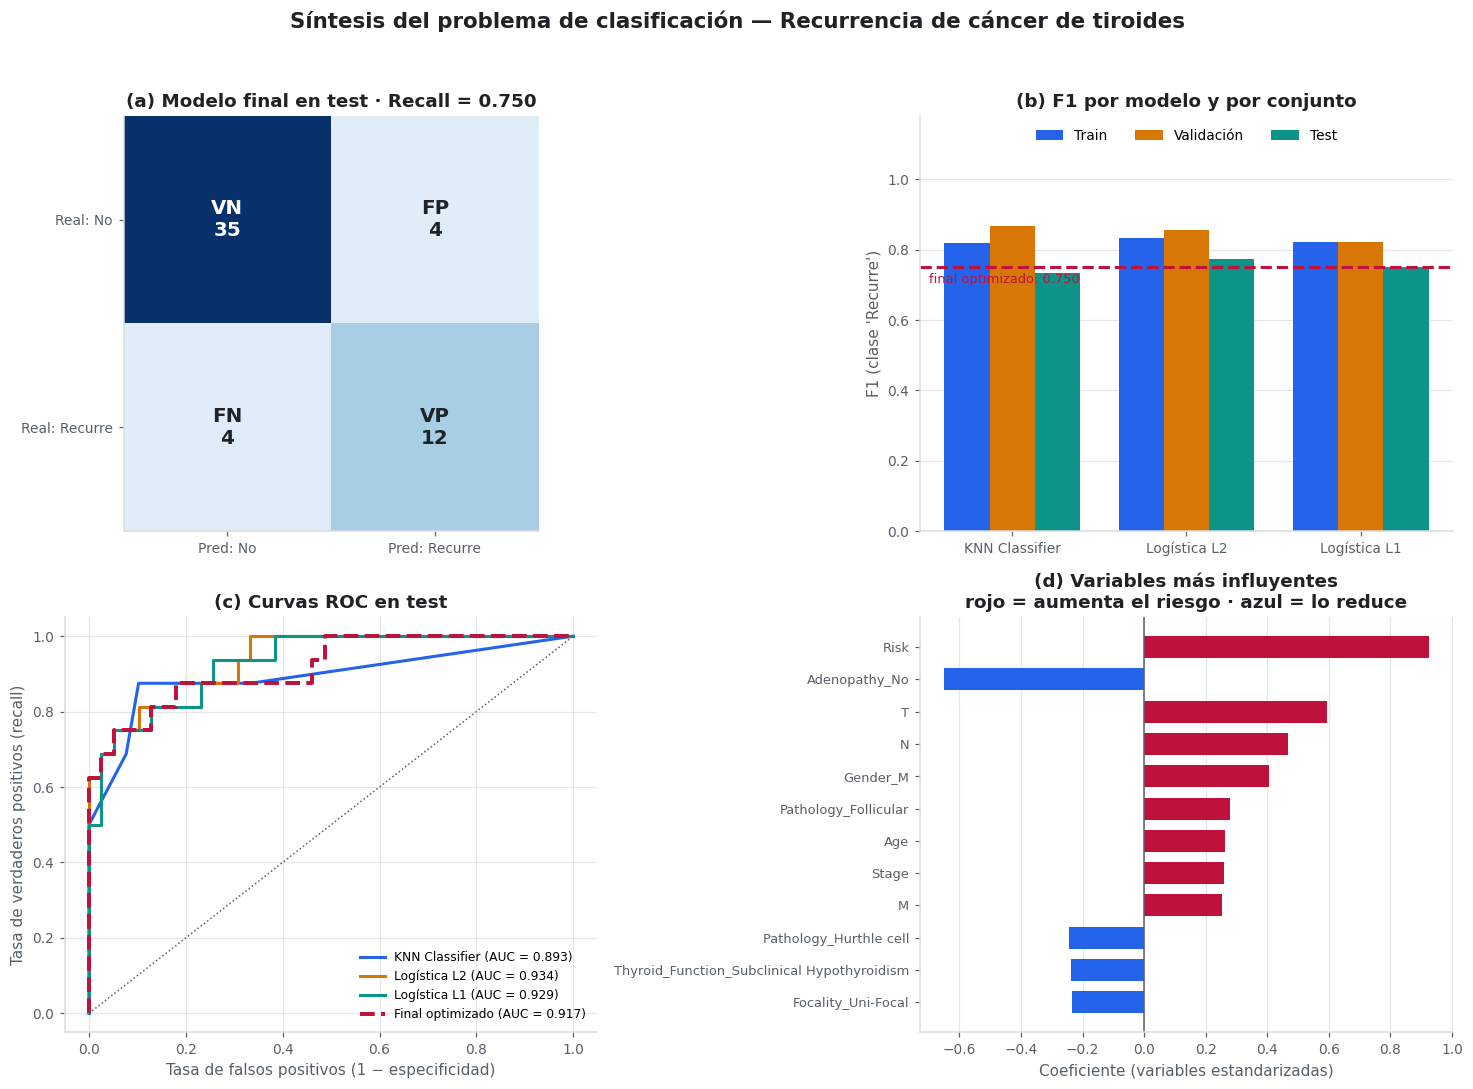

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 10))
fig.suptitle("Síntesis del problema de clasificación — Recurrencia de cáncer de tiroides",
             fontsize=14, fontweight="bold", color=TINTA, y=0.985)

# (a) Matriz de confusión del modelo final en test
ax = axes[0, 0]
im = ax.imshow(cm_final, cmap="Blues", vmin=0)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred: No", "Pred: Recurre"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Real: No", "Real: Recurre"])
etq = [["VN", "FP"], ["FN", "VP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{etq[i][j]}\n{cm_final[i, j]}", ha="center", va="center", fontsize=13,
                fontweight="bold", color="white" if cm_final[i, j] > cm_final.max()/2 else TINTA)
ax.set_title(f"(a) Modelo final en test · Recall = {metricas_finales['Recall']:.3f}")
ax.grid(False)

# (b) F1 por modelo y por conjunto
ax = axes[0, 1]
nombres = list(modelos.keys()); x = np.arange(len(nombres)); w = 0.26
v_tr = [tabla_fase5.loc[n, ("F1", "Train")] for n in nombres]
v_va = [tabla_fase5.loc[n, ("F1", "Validación")] for n in nombres]
v_te = [tabla_test.loc[n, "F1"] for n in nombres]
ax.bar(x - w, v_tr, w, label="Train", color=PALETA[0])
ax.bar(x,     v_va, w, label="Validación", color=PALETA[1])
ax.bar(x + w, v_te, w, label="Test", color=PALETA[2])
ax.axhline(metricas_finales["F1"], color=PALETA[3], linestyle="--", linewidth=2)
ax.text(-0.48, metricas_finales["F1"] - 0.015, f"final optimizado: {metricas_finales['F1']:.3f}",
        color=PALETA[3], fontsize=8.5, va="top", ha="left")
ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=9)
ax.set_ylim(0, 1.18); ax.set_ylabel("F1 (clase 'Recurre')")
ax.set_title("(b) F1 por modelo y por conjunto")
ax.grid(axis="x", visible=False); ax.legend(ncol=3, loc="upper center")

# (c) Curvas ROC en test
ax = axes[1, 0]
for i, nombre in enumerate(modelos):
    fpr, tpr, _ = roc_curve(y_test, predicciones[nombre]["test_proba"])
    ax.plot(fpr, tpr, linewidth=2, color=PALETA[i], label=f"{nombre} (AUC = {auc(fpr, tpr):.3f})")
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_test_final)
ax.plot(fpr_f, tpr_f, linewidth=2.6, color=PALETA[3], linestyle="--",
        label=f"Final optimizado (AUC = {auc(fpr_f, tpr_f):.3f})")
ax.plot([0, 1], [0, 1], color=TINTA_SUAVE, linewidth=1, linestyle=":")
ax.set_xlabel("Tasa de falsos positivos (1 − especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (recall)")
ax.set_title("(c) Curvas ROC en test"); ax.legend(loc="lower right", fontsize=8)

# (d) Importancia de variables del modelo logístico
ax = axes[1, 1]
modelo_interno = modelo_final_clf.named_steps["modelo"]
if hasattr(modelo_interno, "coef_"):
    coefs = pd.Series(modelo_interno.coef_.ravel(),
                      index=modelo_final_clf.named_steps["preprocesador"].get_feature_names_out())
    top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12).iloc[::-1]
    colores = [PALETA[3] if v > 0 else PALETA[0] for v in top.values]
    ax.barh(top.index, top.values, color=colores, height=0.68)
    ax.axvline(0, color=TINTA_SUAVE, linewidth=1)
    ax.set_xlabel("Coeficiente (variables estandarizadas)")
    ax.set_title("(d) Variables más influyentes\nrojo = aumenta el riesgo · azul = lo reduce")
    ax.tick_params(axis="y", labelsize=8.5)
    ax.grid(axis="y", visible=False)
else:
    imp = df.groupby("Risk", observed=True)["Recurred_bin"].mean().reindex(ORDENES["Risk"]) * 100
    ax.bar(imp.index, imp.values, color=PALETA[0], width=0.6)
    ax.set_ylabel("% que recurre"); ax.set_title("(d) Tasa de recurrencia por riesgo ATA")
    ax.grid(axis="x", visible=False)

fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

### Conclusiones del problema de clasificación

**Qué modelo funcionó mejor y por qué.** La **regresión logística con regularización L2** fue el mejor modelo.
La evidencia es convergente aunque no unánime: tuvo el **mejor recall en validación y (empatada con L1) en test**, el **mejor
F1 en test** y el **mayor AUC en test** (gráfica c). La única métrica en la que no ganó fue el F1 de
validación, donde KNN le sacó 0.010 — una ventaja de medio paciente que **no sobrevivió al conjunto de test**,
donde KNN cayó al último lugar. La razón del resultado es estructural y tiene dos partes:

1. **La forma funcional coincide con el fenómeno.** El EDA mostró una relación **monótona** entre gravedad
   (Risk, Stage, TNM) y recurrencia: a mayor estadio, mayor probabilidad, de forma ordenada y sin
   irregularidades locales. La regresión logística modela exactamente eso —un log-odds lineal en los
   predictores— así que su sesgo inductivo es el correcto para este problema.
2. **La razón n/dimensiones castiga a KNN.** Con **254 pacientes de entrenamiento y ~30 features** tras el
   One-Hot, el espacio está **escasamente poblado**: las distancias euclídeas entre pacientes se vuelven
   similares entre sí y "vecino más cercano" pierde significado. Es la **maldición de la dimensionalidad** en
   estado puro.

**El contraste con el notebook de regresión es la conclusión más interesante del taller.** Allí **KNN ganó** y
los modelos lineales quedaron atrás; aquí ocurre exactamente lo contrario, **con los mismos algoritmos**. La
explicación no está en los algoritmos sino en la **geometría de cada problema**:

| | Uber (regresión) | Tiroides (clasificación) |
|---|---|---|
| Observaciones de entrenamiento | ~135 000 | 254 |
| Dimensiones tras el encoding | ~24 | ~30 |
| Densidad del espacio | **Alta** — hay miles de viajes casi idénticos | **Baja** — cada paciente está casi solo |
| Forma de la relación | **No lineal**, con regímenes (tarifa plana JFK) | **Monótona** y aproximadamente lineal en log-odds |
| **Ganador** | **KNN** | **Regresión logística** |

La lección es que **no hay un algoritmo mejor en abstracto**: KNN es un modelo de **bajo sesgo y alta varianza**
que necesita muchos datos por dimensión para funcionar; los modelos lineales regularizados son de **alto sesgo
y baja varianza**, y ese sesgo es una **ventaja** cuando la muestra es pequeña y la relación real es
efectivamente monótona. Es el trade-off sesgo–varianza decidiendo el resultado en ambos casos.

**La segunda lección, metodológica, la dio la Fase 6.** KNN era el primero por F1 en validación y terminó
último en test; la logística L2, elegida por **recall** —el criterio que justificamos clínicamente, no el que
daba el número más alto—, se mantuvo primera en recall en ambos conjuntos (empatada con L1 en test). Seleccionar por "la métrica más alta en validación" habría llevado a KNN, que en este test quedó último. Con 55 pacientes por partición esto es una observación de este experimento y no una prueba general: una diferencia de medio paciente en validación no debería decidir la elección, y un criterio anclado en el costo real de cada tipo de error (recall) es más defendible clínicamente.

**Sobre el efecto del parámetro de regularización.** `C` (inverso de la fuerza de penalización) controla
directamente ese trade-off: `C` pequeño ⇒ mucha penalización ⇒ coeficientes pequeños ⇒ alto sesgo; `C` grande
⇒ modelo casi sin restricciones ⇒ alta varianza. La comparación L1 vs. L2 añade otra dimensión: **L2 encoge
los coeficientes y reparte el peso** entre predictores correlacionados, mientras que **L1 selecciona uno y
anula el resto**. Como la Gráfica 5 mostró colinealidad entre variables **todas clínicamente informativas**
(edad ↔ riesgo ↔ estadio), repartir resultó preferible a eliminar. L1 tendría ventaja si hubiera muchas
variables irrelevantes, que no es el caso con 15 predictores escogidos por criterio clínico. Tanto KNN como la penalización L1/L2 dependen de la escala de las variables, por lo que se estandarizaron (punto 10).

**Qué limpieza fue más determinante.** Sin ninguna duda, **excluir la columna `Response`**. Es la decisión que
más cambia el resultado del estudio: incluirla habría producido un modelo aparentemente excelente (una regla de una línea sobre `Response` ya acierta 94.2 %, punto 6) y **completamente inútil**, porque esa variable no existe en el momento clínico en que
se necesita la predicción. Ninguna validación cruzada, ninguna partición y ningún `Pipeline` habrían detectado
ese problema: **la fuga del target sólo se detecta entendiendo el dominio**. En segundo lugar, la
**codificación ordinal de Risk/T/N/M/Stage**: con 254 observaciones, representar la gravedad con 5 columnas
ordenadas en lugar de 20 columnas binarias casi vacías es la opción más parsimoniosa (no se comparó experimentalmente con One-Hot); la gráfica (d) es coherente con ello: `Risk`, `T` y `N` figuran entre los coeficientes de mayor magnitud, junto con `Adenopathy_No` y `Gender_M`.

**Limitaciones del estudio.**

1. **Tamaño muestral pequeño.** 364 pacientes, 55 en test (~16 positivos). Cada paciente mal clasificado mueve
   el recall ~6 puntos porcentuales. Las diferencias observadas entre modelos deben leerse con esa
   granularidad, y muchas de ellas no son estadísticamente significativas.
2. **Cohorte de un solo centro.** El modelo refleja la práctica clínica y la demografía de ese centro; su
   **validez externa** está sin verificar. Habría que validarlo en una cohorte independiente antes de
   cualquier uso real.
3. **Ausencia de variables clínicas clave.** No hay tiroglobulina postoperatoria ni sus anticuerpos, tamaño
   tumoral en milímetros, márgenes quirúrgicos, invasión linfovascular, dosis de yodo radiactivo ni mutaciones
   moleculares (BRAF V600E, TERT). Son precisamente los predictores más potentes en la literatura reciente.
4. **Sin variable temporal.** `Recurred` es binaria y no dice **cuándo** ocurrió la recurrencia. Un análisis de
   supervivencia (Kaplan-Meier, modelo de Cox) sería metodológicamente más apropiado, porque un paciente
   marcado "No" puede simplemente no haber recurrido **todavía** (censura a la derecha).
5. **Supuesto de equiespaciado en las ordinales.** Al codificar T1a=0 … T4b=6 asumimos que todos los saltos
   valen lo mismo, lo cual es una aproximación.
6. **Umbral fijo en 0.5.** Optimizamos F1 con el umbral por defecto, cuando el contexto clínico justifica
   bajarlo para privilegiar el recall.

**Preguntas abiertas.** ¿Se mantendría el desempeño en una cohorte externa de otro país o sistema de salud?
¿Cuánto aportarían la tiroglobulina y el estado mutacional BRAF/TERT? ¿Un modelo de supervivencia daría una
respuesta más útil al clínico —*cuándo* vigilar, no sólo *a quién*? ¿Qué umbral de probabilidad equilibra
mejor el costo de un seguimiento intensivo innecesario frente al de una recurrencia detectada tarde, y cómo se
consensúa esa cifra con el equipo médico? Y, sobre todo, ¿aceptarían los clínicos un modelo de apoyo a la
decisión que sólo usa variables disponibles al diagnóstico, cuando en la práctica ya cuentan con la respuesta
al tratamiento a los 12 meses?